In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import seaborn as sns
import missingno as msno

from sklearn.feature_selection import mutual_info_classif

# Общий Анализ

In [4]:
df = pd.read_parquet('train_data/train_data_0.pq')

In [5]:
df.shape

(1974724, 61)

In [6]:
df.head()

,id,rn,pre_since_opened,pre_since_confirmed,pre_pterm,pre_fterm,pre_till_pclose,pre_till_fclose,pre_loans_credit_limit,pre_loans_next_pay_summ,...,enc_paym_21,enc_paym_22,enc_paym_23,enc_paym_24,enc_loans_account_holder_type,enc_loans_credit_status,enc_loans_credit_type,enc_loans_account_cur,pclose_flag,fclose_flag
0,0,1,18,9,2,3,16,10,11,3,...,3,3,3,4,1,3,4,1,0,0
1,0,2,18,9,14,14,12,12,0,3,...,0,0,0,4,1,3,4,1,0,0
2,0,3,18,9,4,8,1,11,11,0,...,0,0,0,4,1,2,3,1,1,1
3,0,4,4,1,9,12,16,7,12,2,...,3,3,3,4,1,3,1,1,0,0
4,0,5,5,12,15,2,11,12,10,2,...,3,3,3,4,1,3,4,1,0,0


In [7]:
targets = pd.read_csv('train_target.csv')
targets.head()

,id,flag
0,0,0
1,1,0
2,2,0
3,3,0
4,4,0


In [8]:
targets.shape

(3000000, 2)

# Разведочный анализ df

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1974724 entries, 0 to 1974723
Data columns (total 61 columns):
 #   Column                         Dtype
---  ------                         -----
 0   id                             int64
 1   rn                             int64
 2   pre_since_opened               int64
 3   pre_since_confirmed            int64
 4   pre_pterm                      int64
 5   pre_fterm                      int64
 6   pre_till_pclose                int64
 7   pre_till_fclose                int64
 8   pre_loans_credit_limit         int64
 9   pre_loans_next_pay_summ        int64
 10  pre_loans_outstanding          int64
 11  pre_loans_total_overdue        int64
 12  pre_loans_max_overdue_sum      int64
 13  pre_loans_credit_cost_rate     int64
 14  pre_loans5                     int64
 15  pre_loans530                   int64
 16  pre_loans3060                  int64
 17  pre_loans6090                  int64
 18  pre_loans90                    int64
 19  

In [9]:
df.describe()

,id,rn,pre_since_opened,pre_since_confirmed,pre_pterm,pre_fterm,pre_till_pclose,pre_till_fclose,pre_loans_credit_limit,pre_loans_next_pay_summ,...,enc_paym_21,enc_paym_22,enc_paym_23,enc_paym_24,enc_loans_account_holder_type,enc_loans_credit_status,enc_loans_credit_type,enc_loans_account_cur,pclose_flag,fclose_flag
count,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,...,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06
mean,1.259465e+05,6.537471e+00,9.271325e+00,8.330264e+00,8.299071e+00,8.309444e+00,6.991781e+00,8.337011e+00,9.740888e+00,2.399848e+00,...,2.313242e+00,2.343014e+00,2.376717e+00,3.576724e+00,1.027562e+00,2.694898e+00,3.353936e+00,1.002386e+00,1.721385e-01,2.239336e-01
std,7.226981e+04,5.121167e+00,5.773757e+00,4.593511e+00,5.245598e+00,4.464844e+00,5.184165e+00,4.233992e+00,5.799625e+00,1.376391e+00,...,1.247674e+00,1.228473e+00,1.205555e+00,1.035586e+00,2.767022e-01,4.891363e-01,1.057304e+00,5.909327e-02,3.775009e-01,4.168782e-01
min,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,6.344100e+04,3.000000e+00,4.000000e+00,5.000000e+00,4.000000e+00,6.000000e+00,1.000000e+00,5.000000e+00,5.000000e+00,2.000000e+00,...,3.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,1.000000e+00,2.000000e+00,3.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
50%,1.263750e+05,5.000000e+00,9.000000e+00,9.000000e+00,8.000000e+00,8.000000e+00,6.000000e+00,1.000000e+01,1.000000e+01,2.000000e+00,...,3.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,1.000000e+00,3.000000e+00,4.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
75%,1.889970e+05,9.000000e+00,1.400000e+01,1.100000e+01,1.300000e+01,1.200000e+01,1.200000e+01,1.100000e+01,1.500000e+01,2.000000e+00,...,3.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,1.000000e+00,3.000000e+00,4.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
max,2.499990e+05,5.100000e+01,1.900000e+01,1.700000e+01,1.700000e+01,1.600000e+01,1.600000e+01,1.500000e+01,1.900000e+01,6.000000e+00,...,3.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,6.000000e+00,6.000000e+00,5.000000e+00,3.000000e+00,1.000000e+00,1.000000e+00


In [10]:
len(df[df.duplicated()])

0

In [11]:
missing_cols = df.isnull().sum()
missing_cols = missing_cols[missing_cols > 0]

print("Колонки с пропусками:")
print(missing_cols)

Колонки с пропусками:
Series([], dtype: int64)


<Axes: >

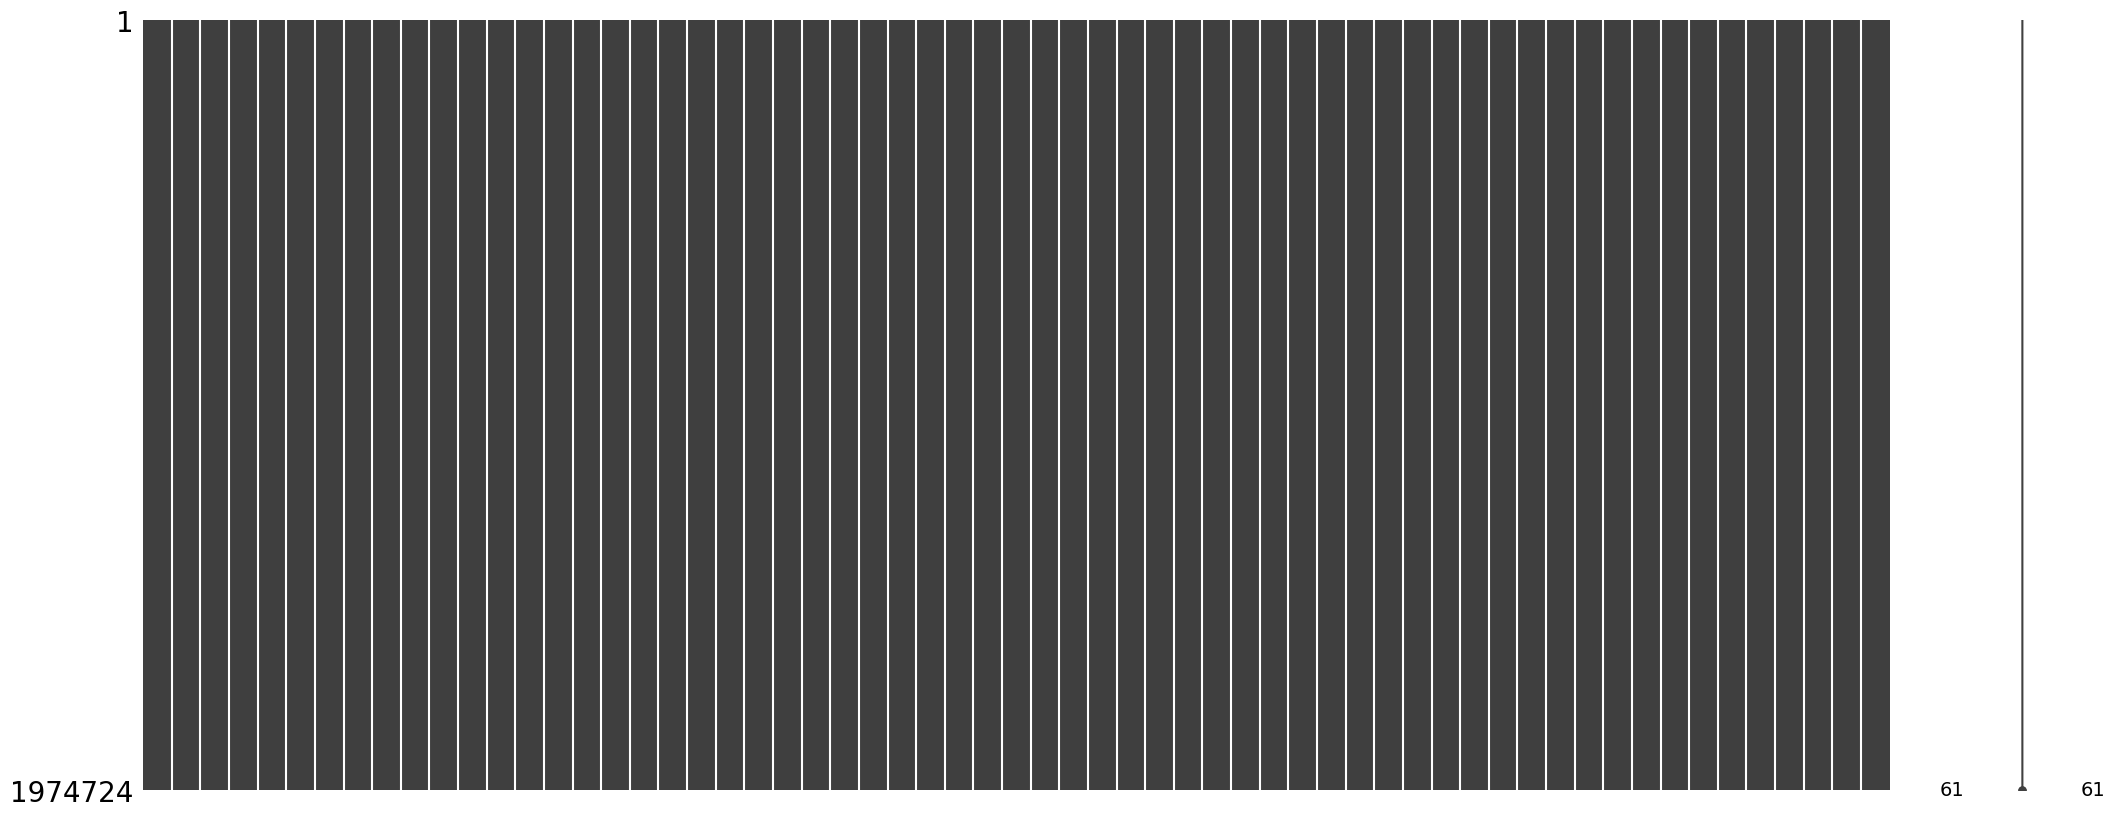

In [12]:
msno.matrix(df)

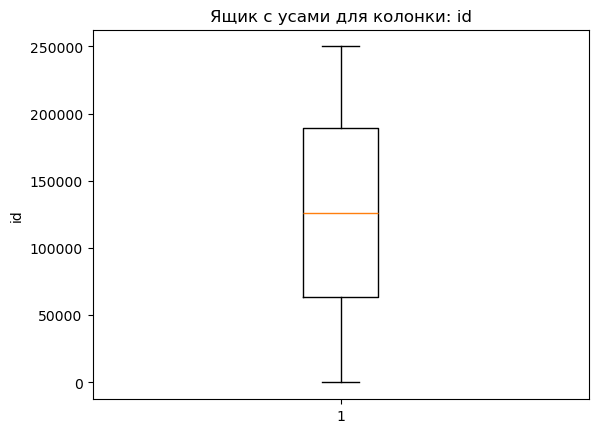

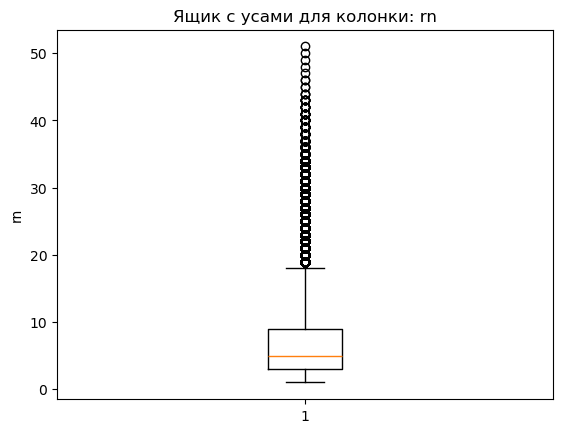

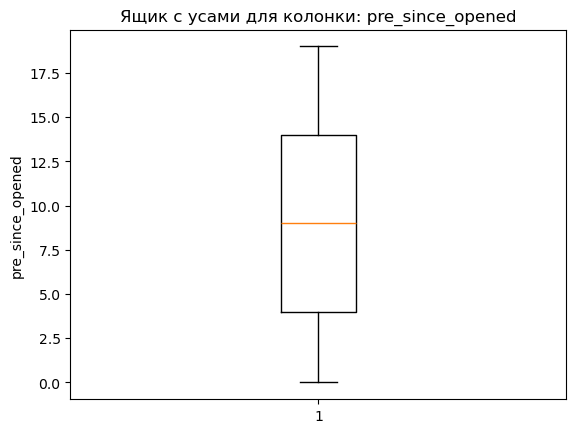

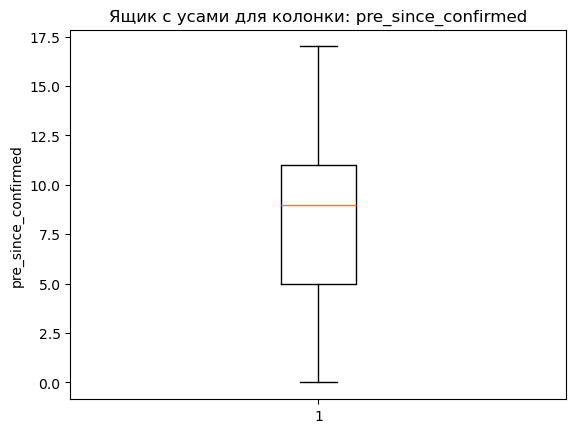

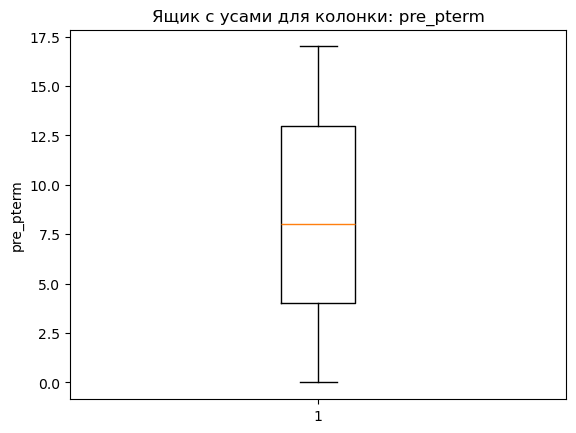

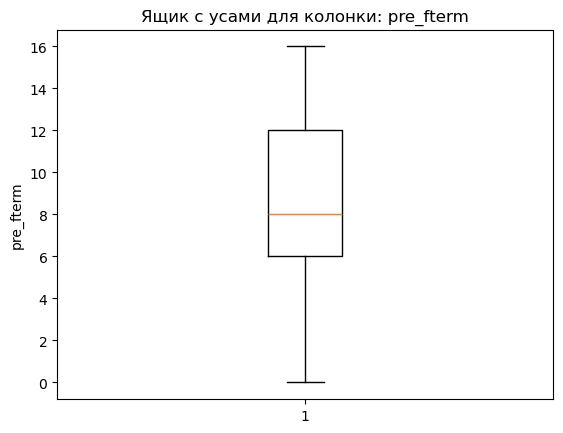

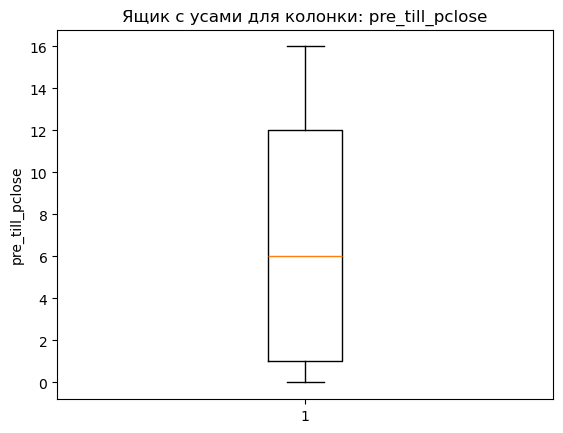

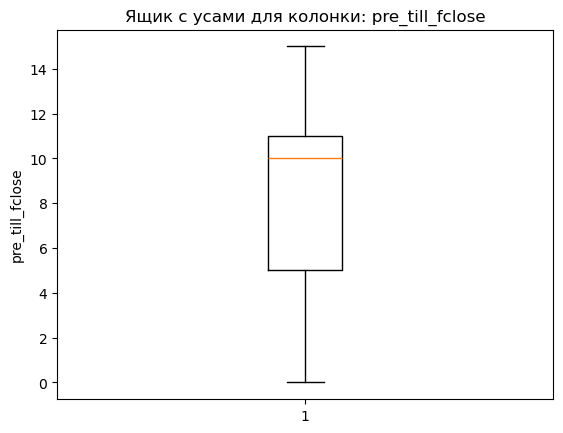

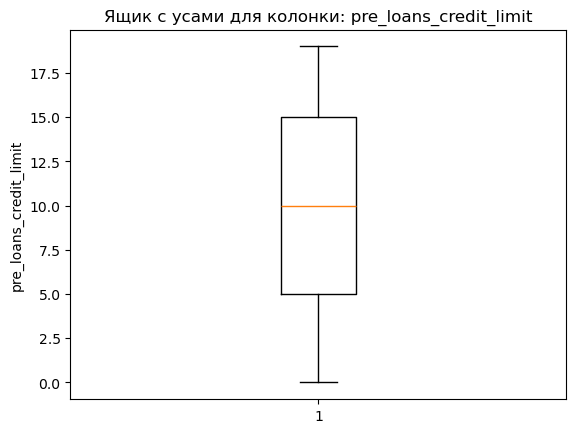

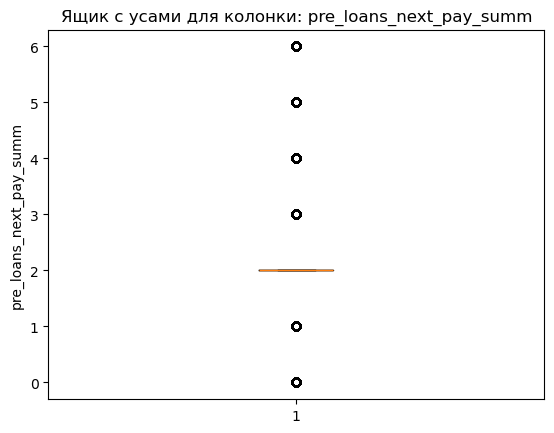

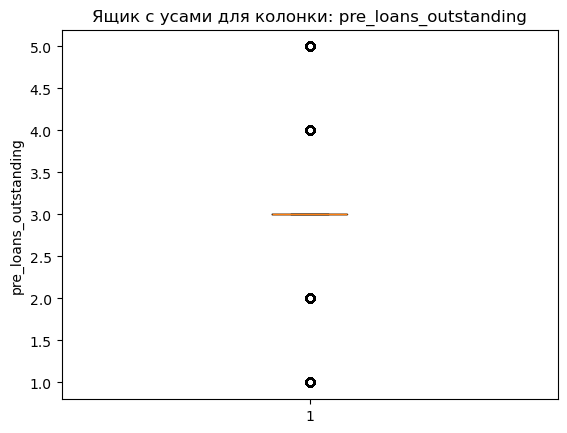

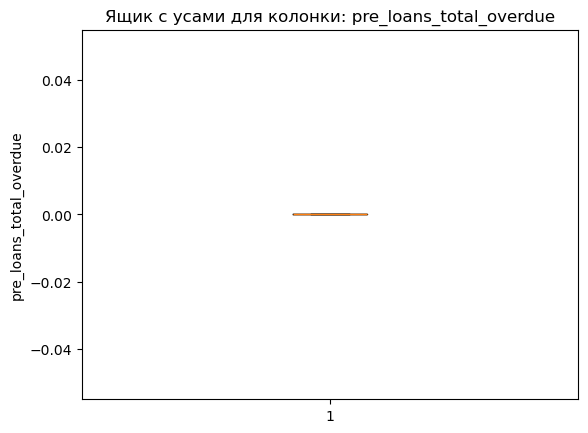

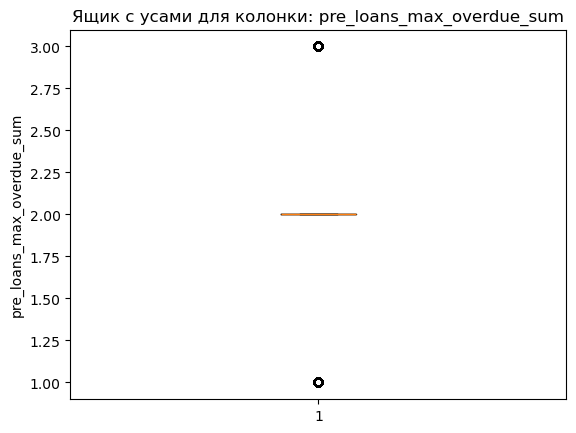

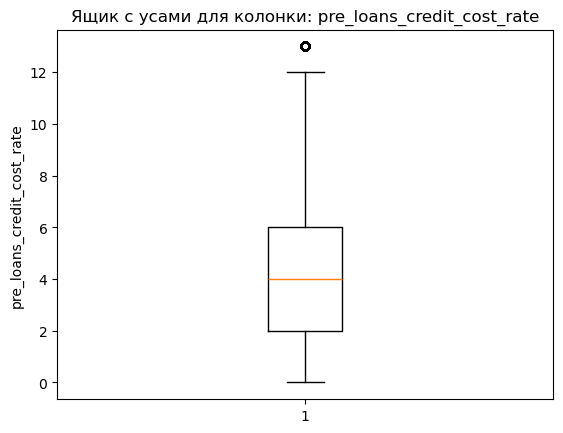

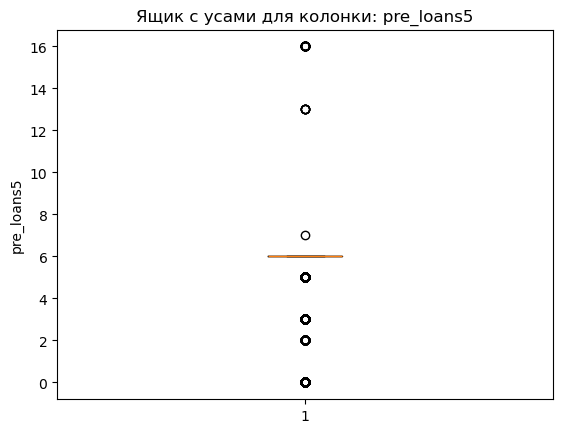

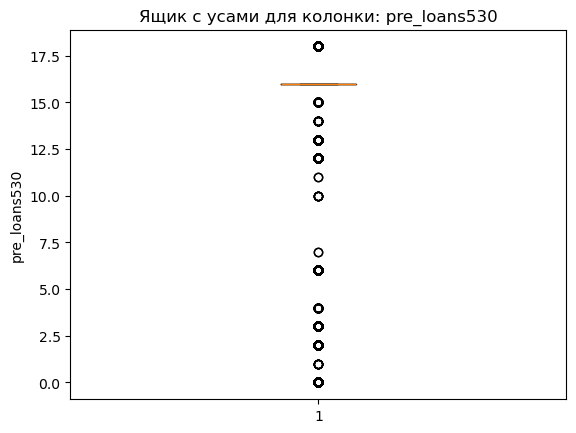

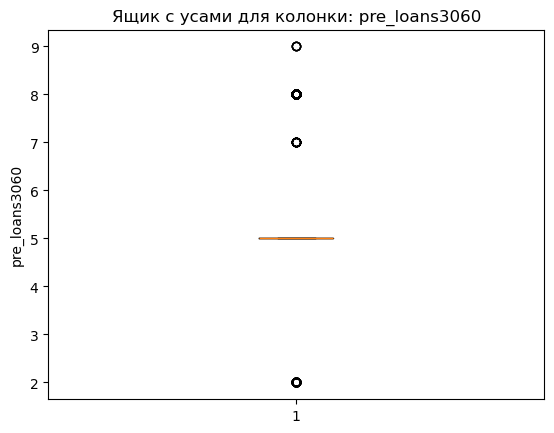

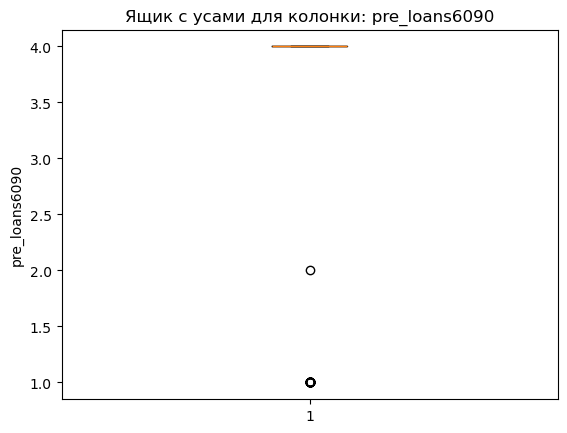

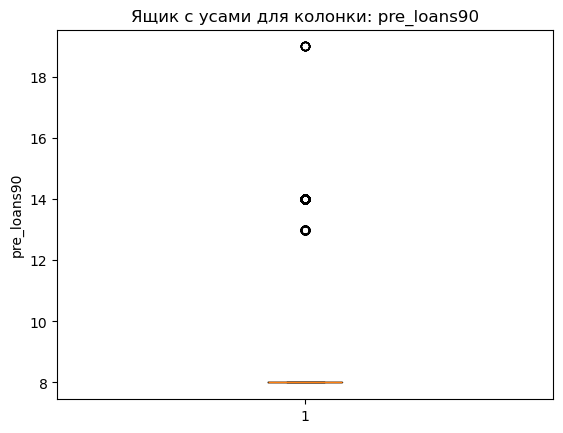

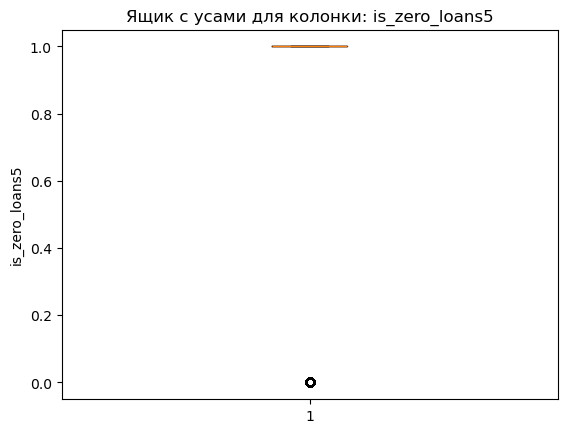

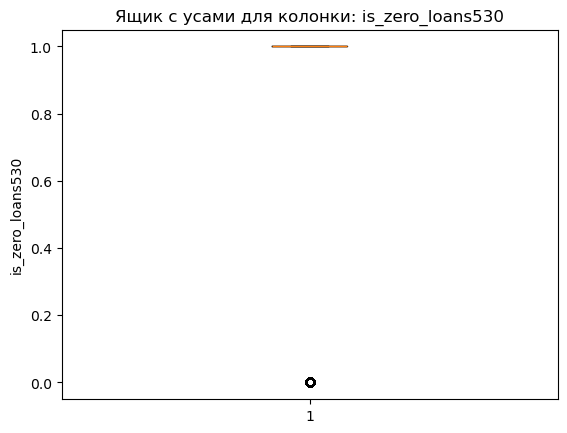

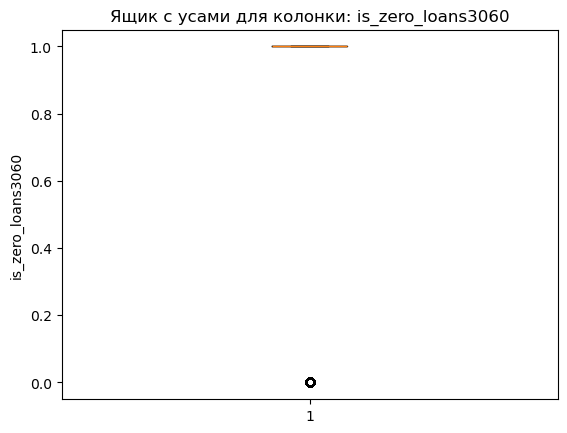

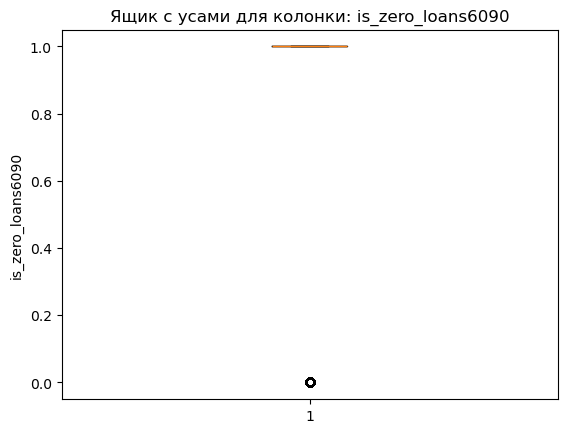

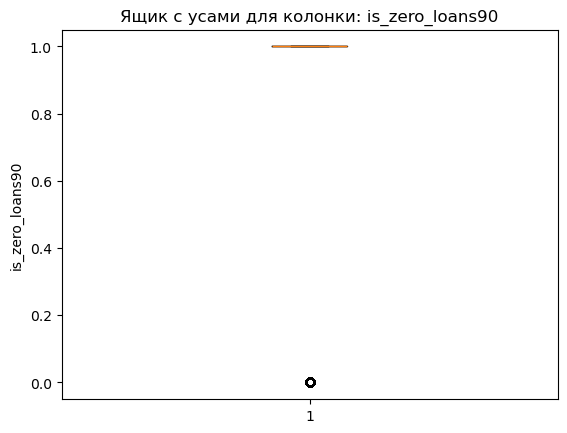

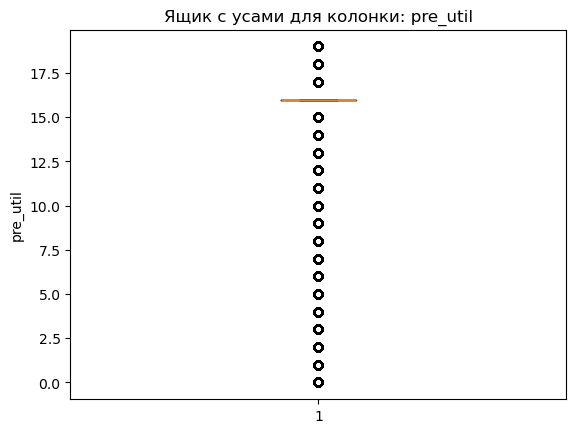

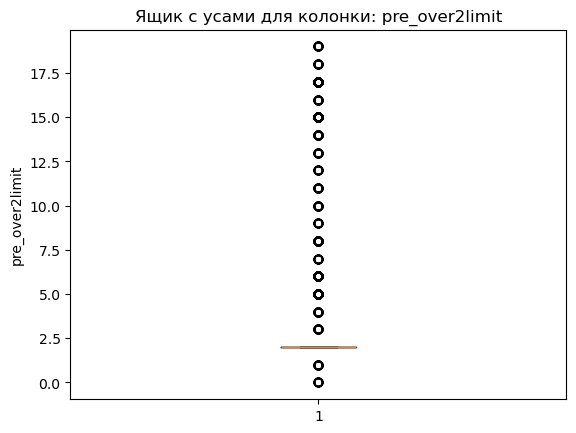

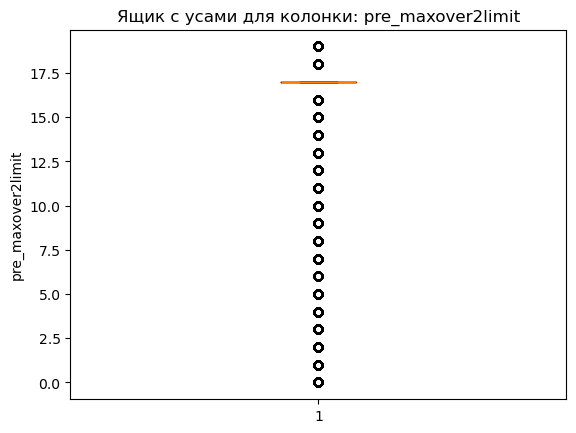

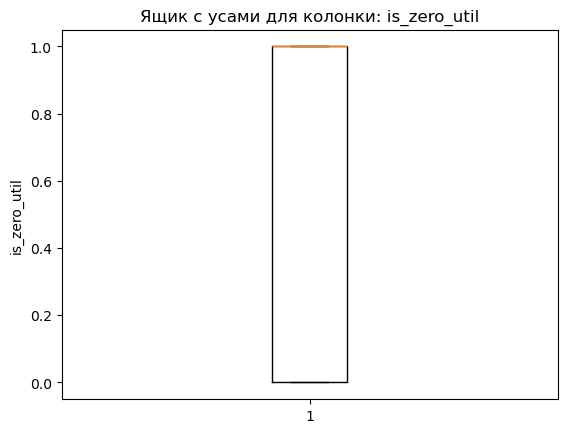

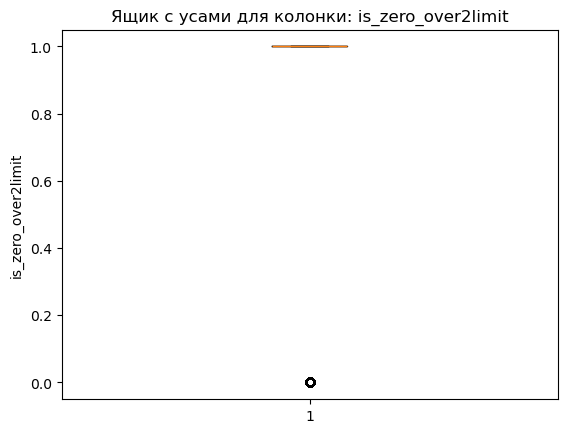

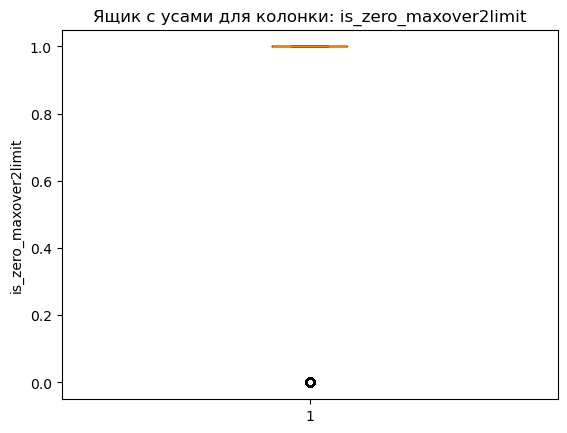

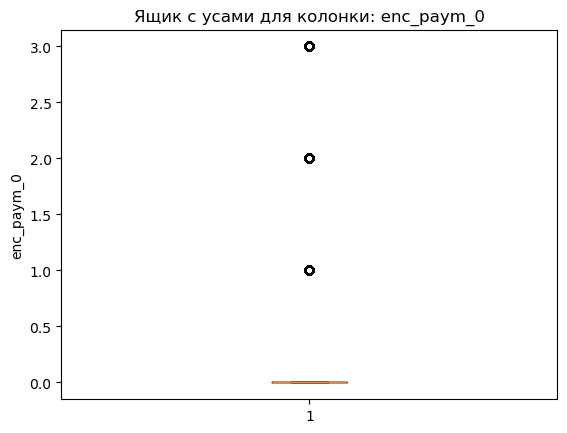

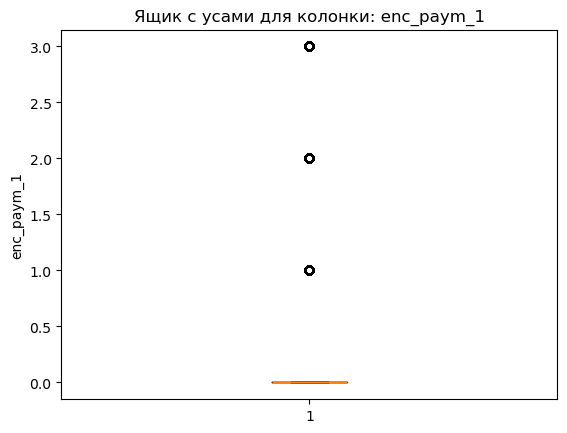

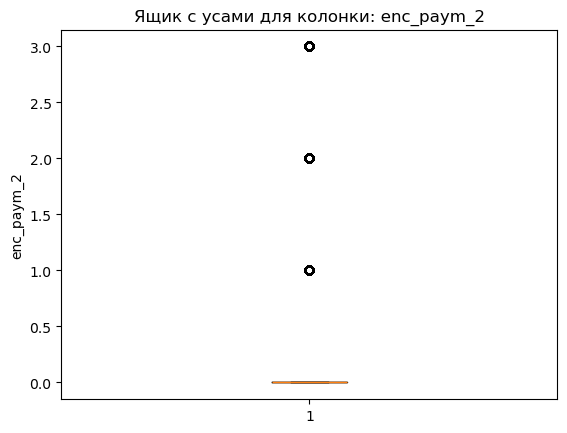

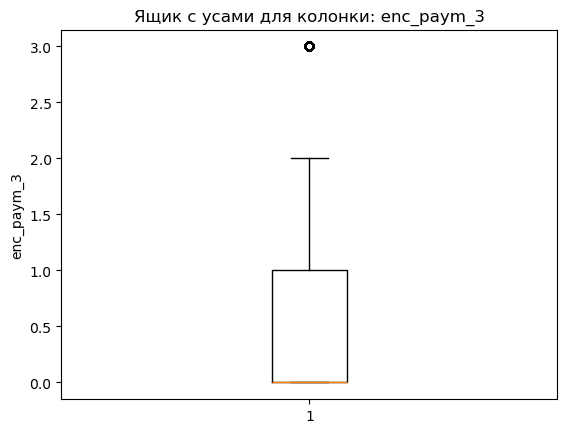

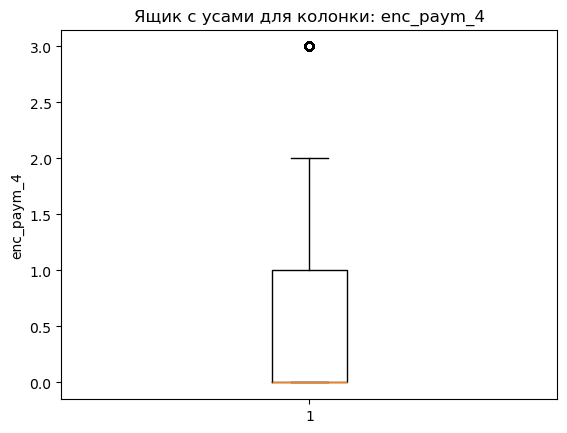

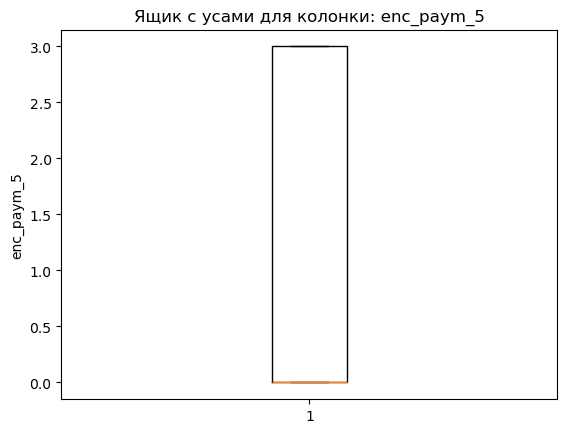

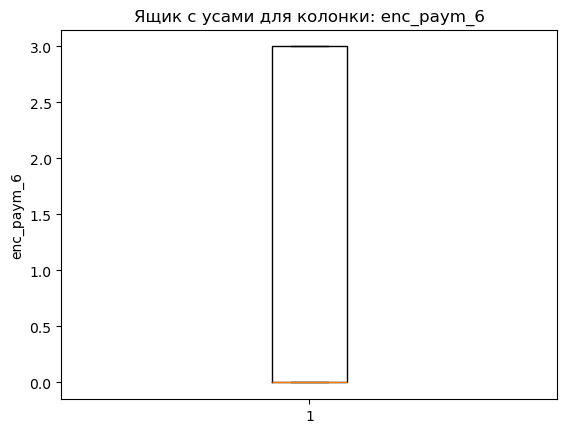

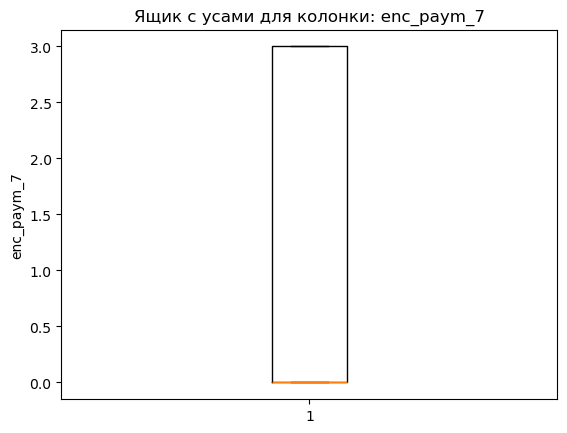

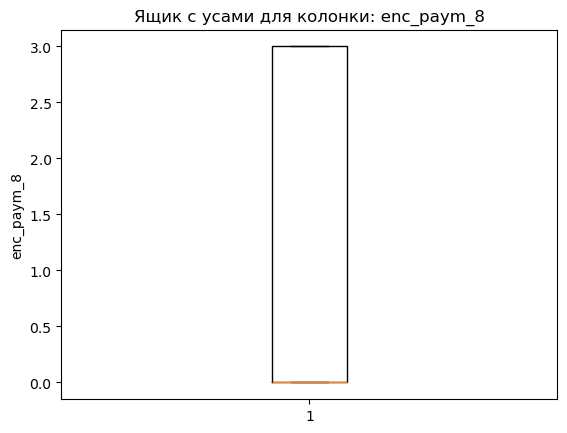

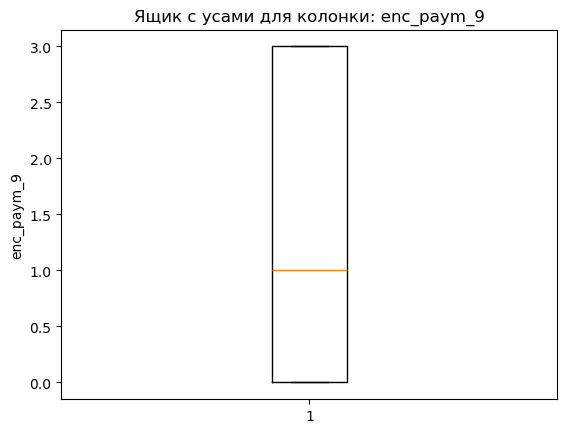

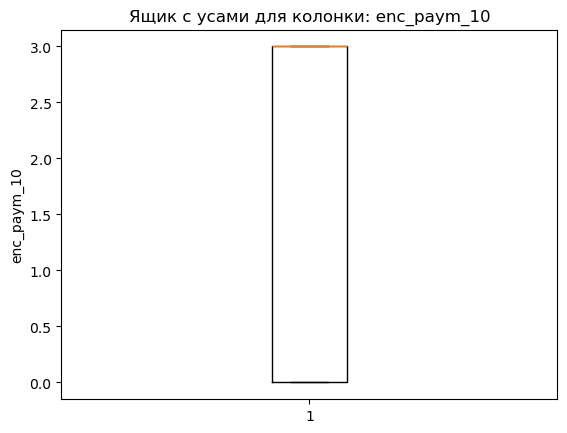

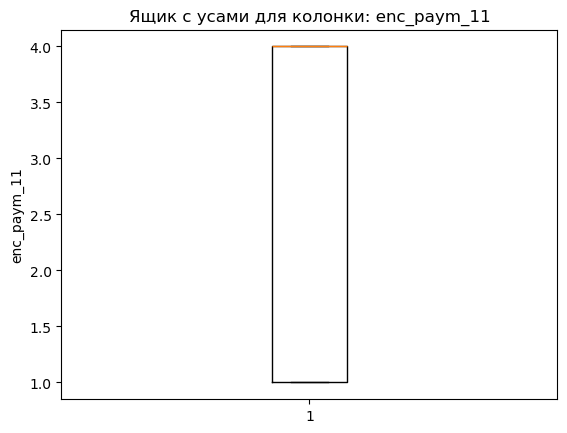

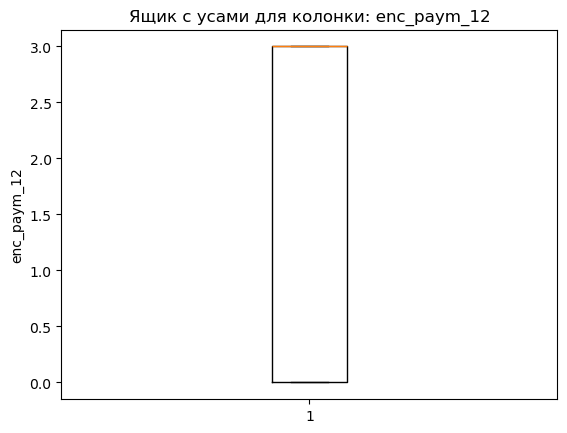

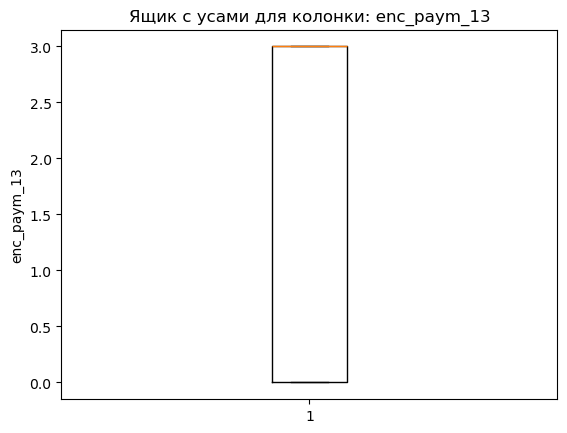

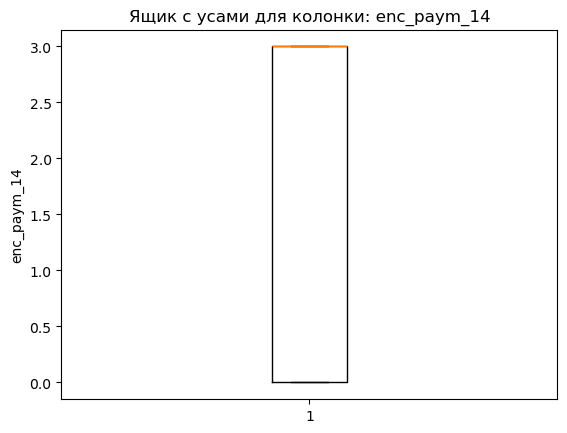

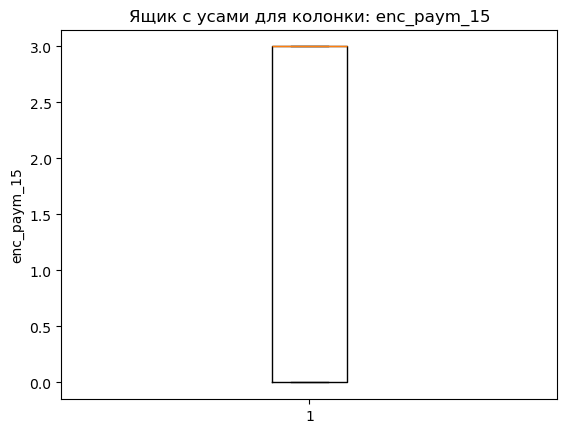

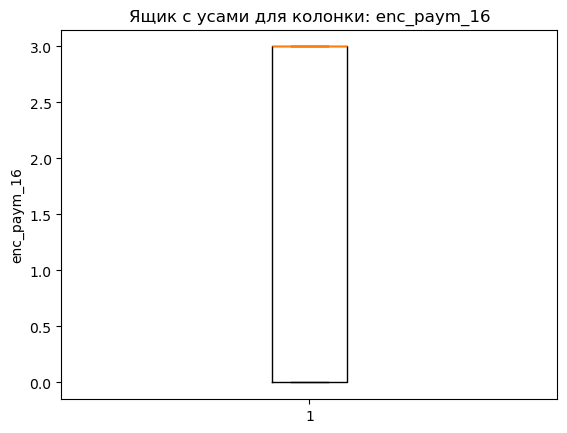

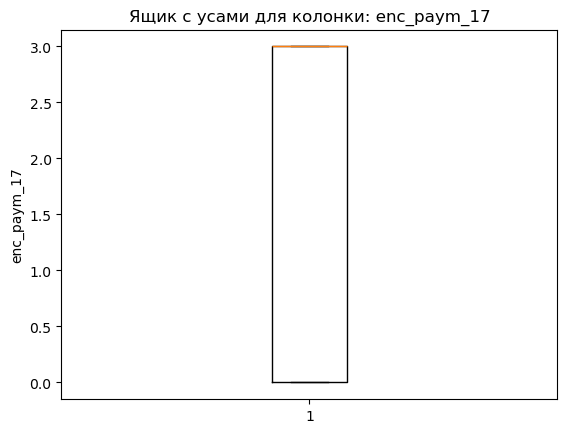

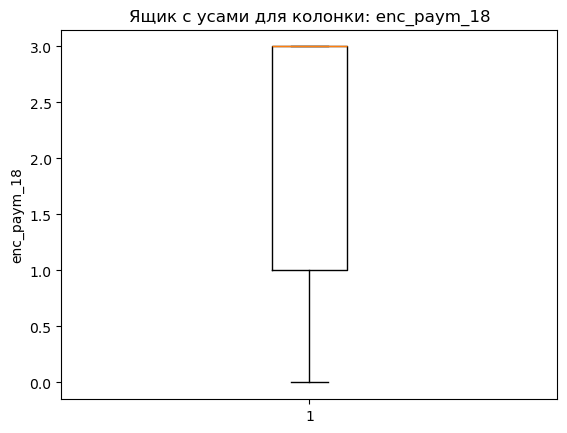

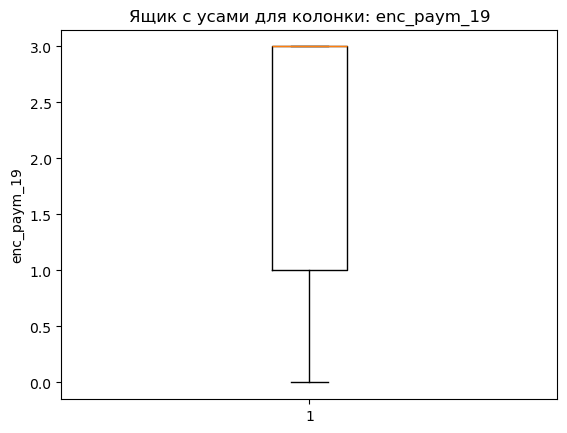

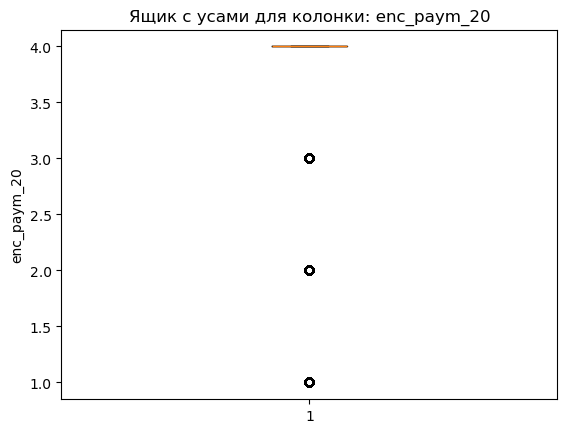

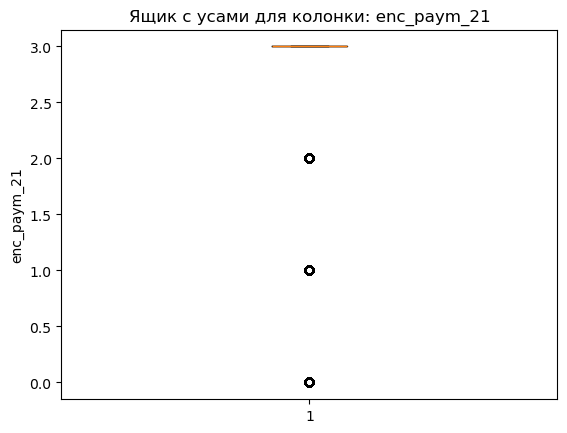

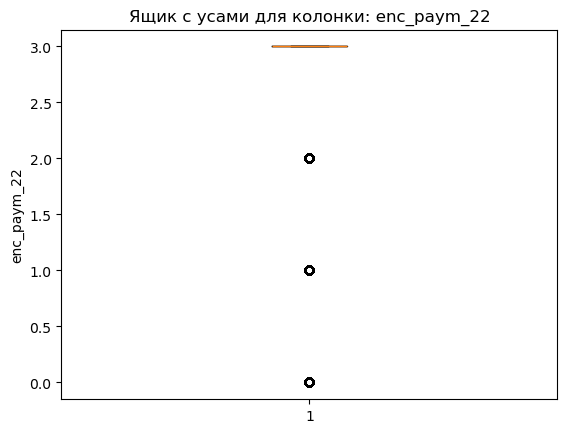

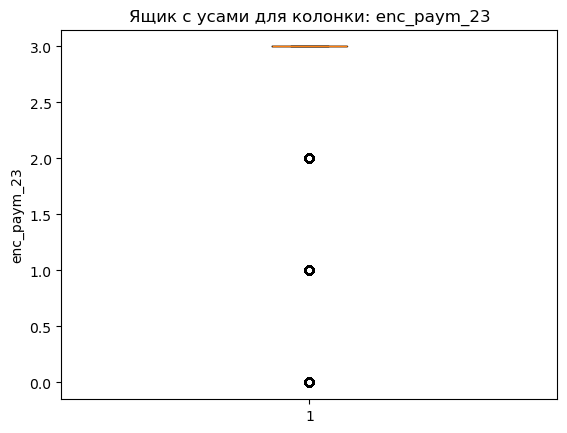

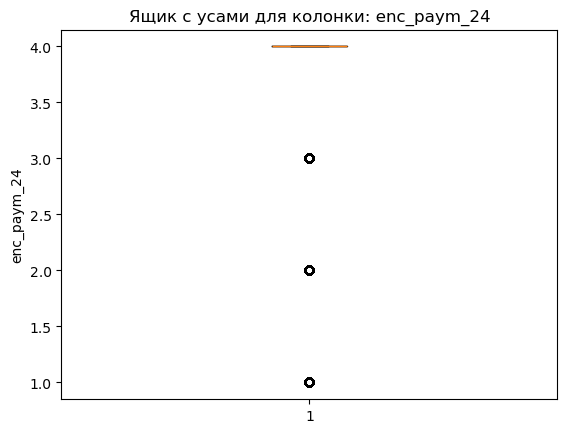

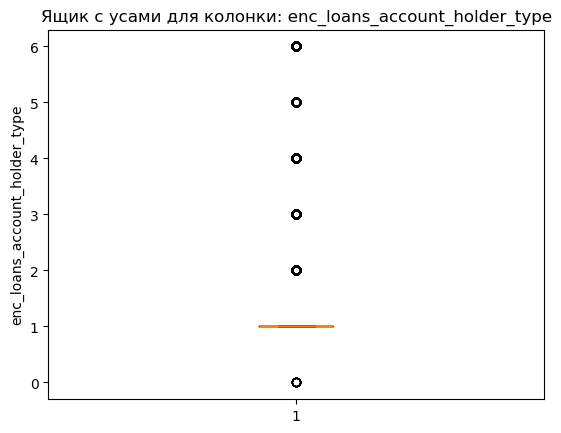

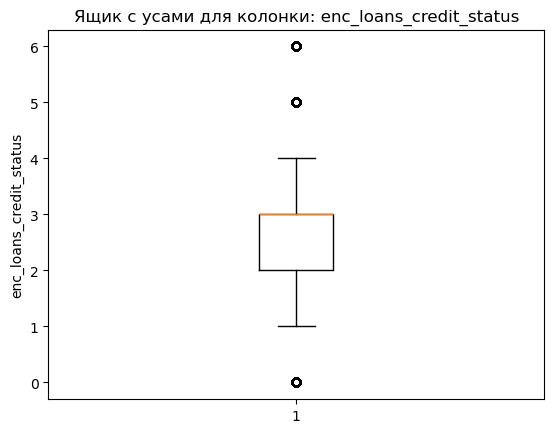

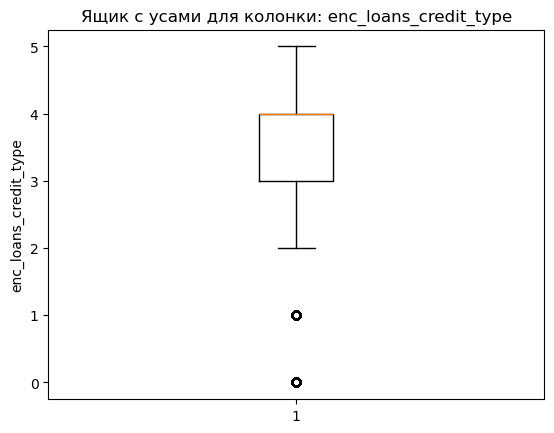

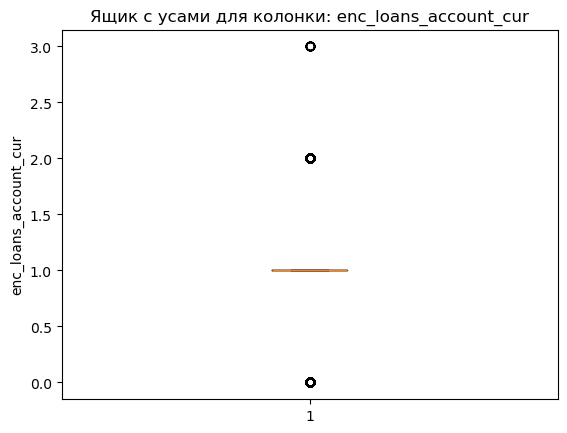

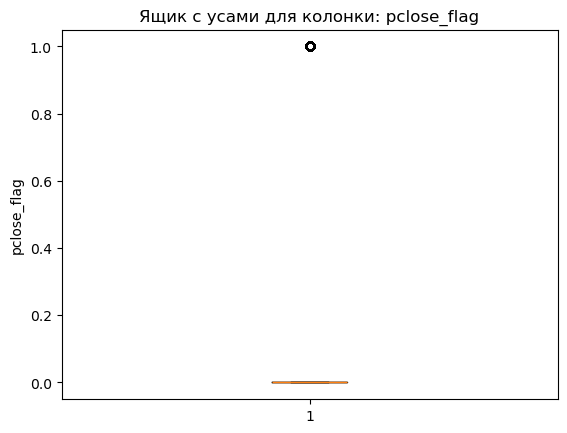

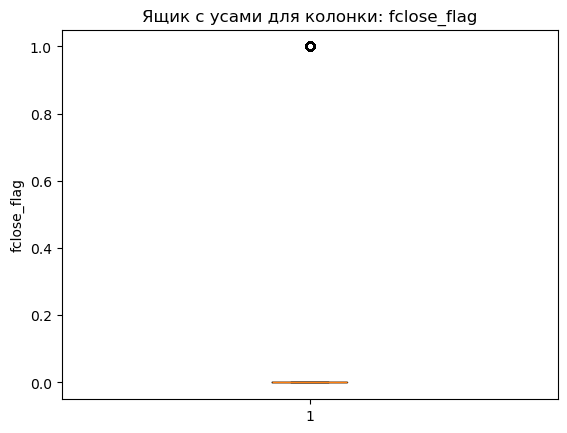

In [13]:
cols = df.columns
for col in cols:
    plt.figure()  
    plt.boxplot(df[col])  
    plt.title(f'Ящик с усами для колонки: {col}')  
    plt.ylabel(col)  
    plt.show() 

In [14]:
def get_anomaly_columns(df, multiplier=1.5):
    """Возвращает список столбцов с аномалиями"""
    anomaly_cols = []
    
    for col in df.select_dtypes(include=[np.number]).columns:
        data = df[col].dropna()
        if len(data) < 3:
            continue
            
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        
        anomalies = data[(data < Q1 - multiplier * IQR) | (data > Q3 + multiplier * IQR)]
        
        if len(anomalies) > 0:
            anomaly_cols.append(col)
    
    return anomaly_cols

columns_with_anomalies = get_anomaly_columns(df)
print("Столбцы с аномалиями:", columns_with_anomalies)

Столбцы с аномалиями: ['rn', 'pre_loans_next_pay_summ', 'pre_loans_outstanding', 'pre_loans_max_overdue_sum', 'pre_loans_credit_cost_rate', 'pre_loans5', 'pre_loans530', 'pre_loans3060', 'pre_loans6090', 'pre_loans90', 'is_zero_loans5', 'is_zero_loans530', 'is_zero_loans3060', 'is_zero_loans6090', 'is_zero_loans90', 'pre_util', 'pre_over2limit', 'pre_maxover2limit', 'is_zero_over2limit', 'is_zero_maxover2limit', 'enc_paym_0', 'enc_paym_1', 'enc_paym_2', 'enc_paym_3', 'enc_paym_4', 'enc_paym_20', 'enc_paym_21', 'enc_paym_22', 'enc_paym_23', 'enc_paym_24', 'enc_loans_account_holder_type', 'enc_loans_credit_status', 'enc_loans_credit_type', 'enc_loans_account_cur', 'pclose_flag', 'fclose_flag']


Histogram for rn


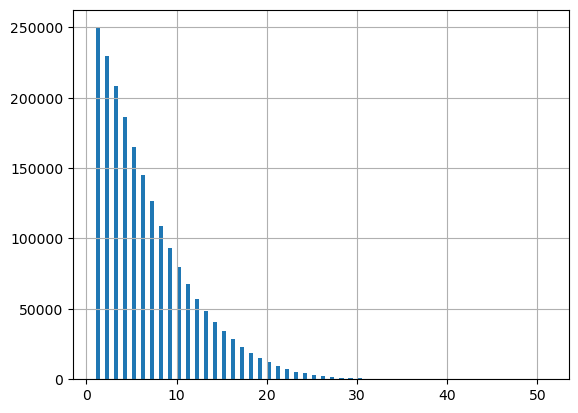

Histogram for pre_loans_next_pay_summ


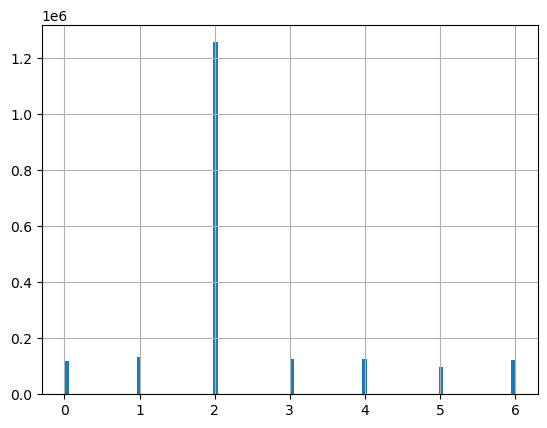

Histogram for pre_loans_outstanding


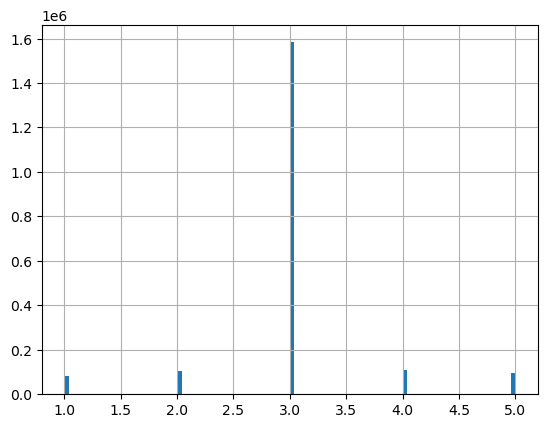

Histogram for pre_loans_max_overdue_sum


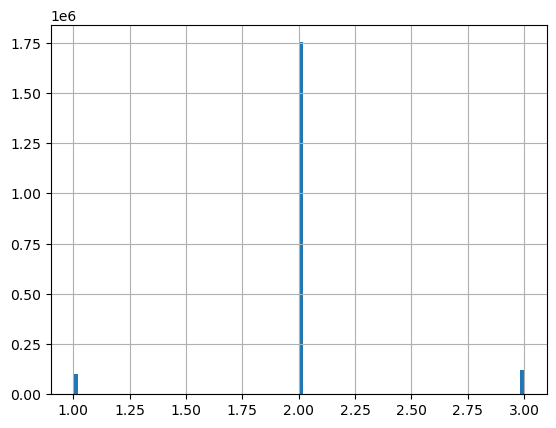

Histogram for pre_loans_credit_cost_rate


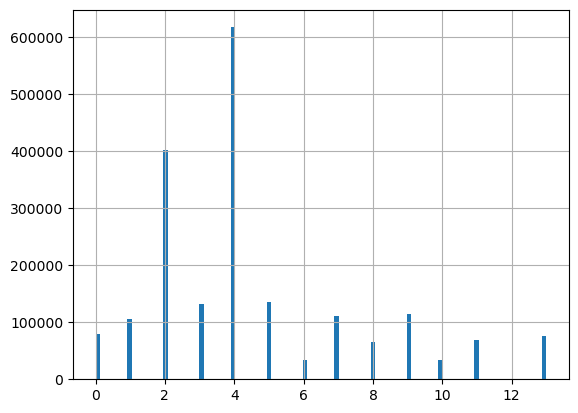

Histogram for pre_loans5


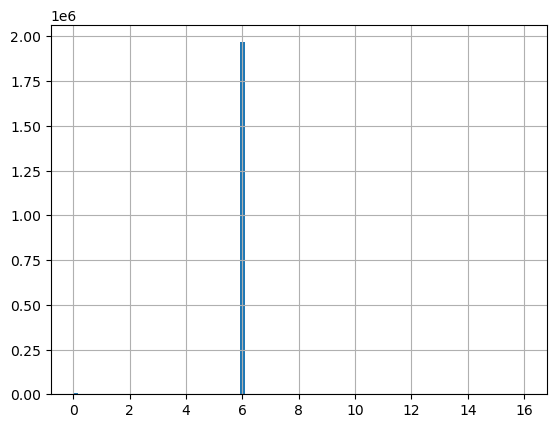

Histogram for pre_loans530


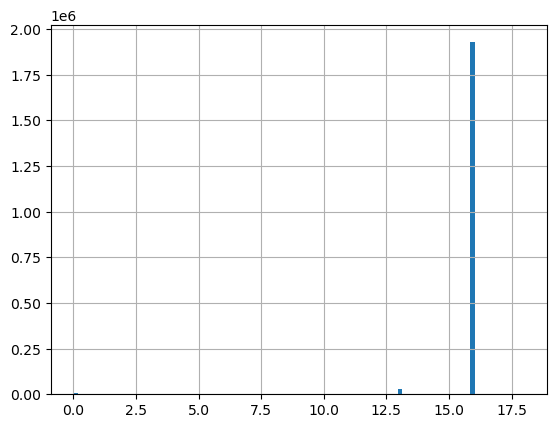

Histogram for pre_loans3060


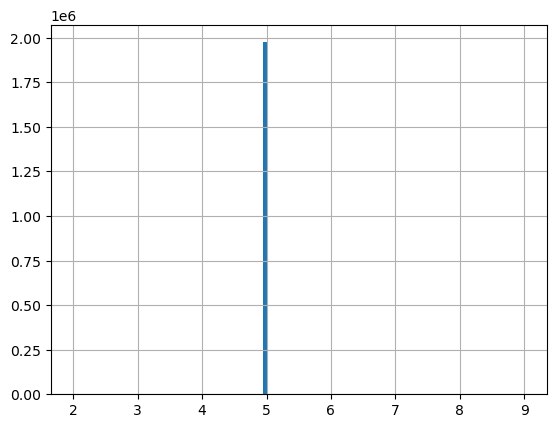

Histogram for pre_loans6090


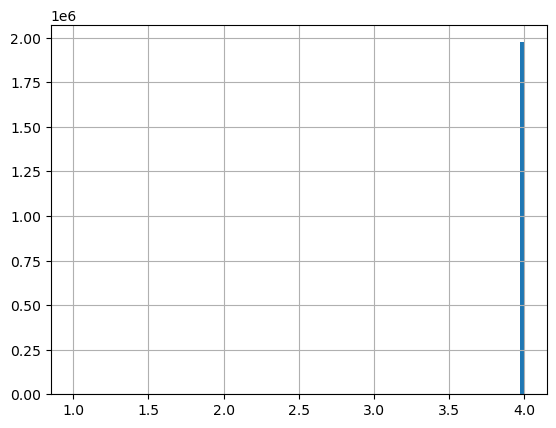

Histogram for pre_loans90


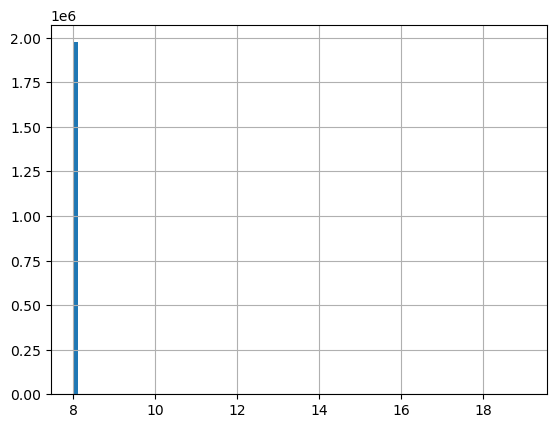

Histogram for is_zero_loans5


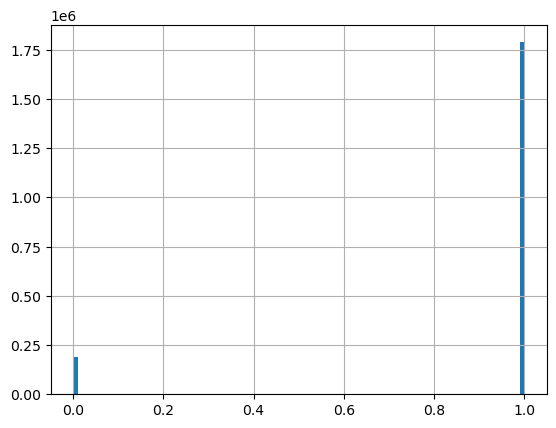

Histogram for is_zero_loans530


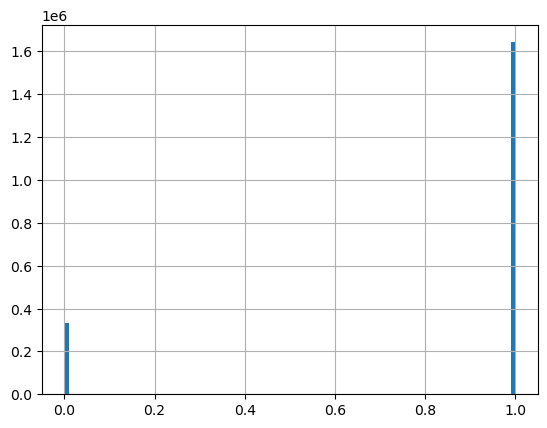

Histogram for is_zero_loans3060


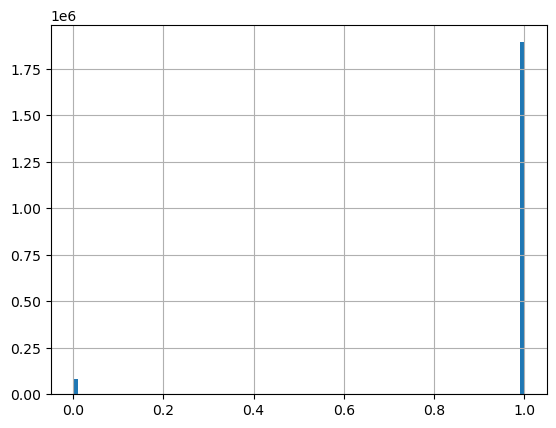

Histogram for is_zero_loans6090


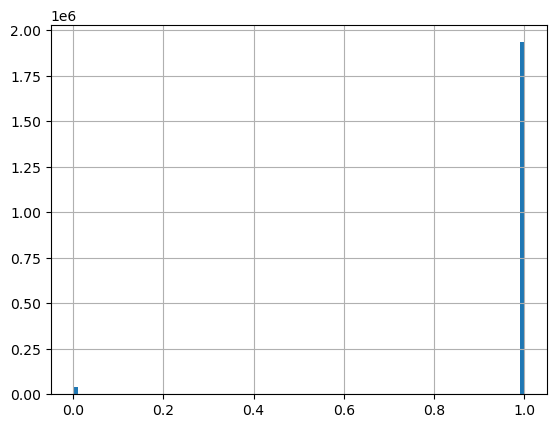

Histogram for is_zero_loans90


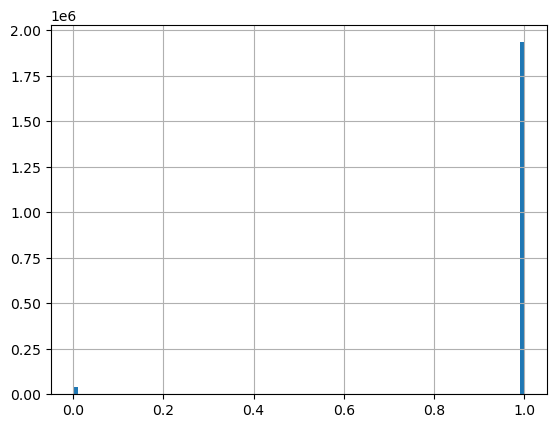

Histogram for pre_util


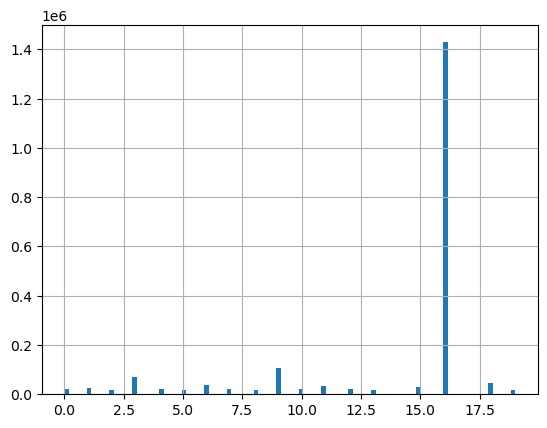

Histogram for pre_over2limit


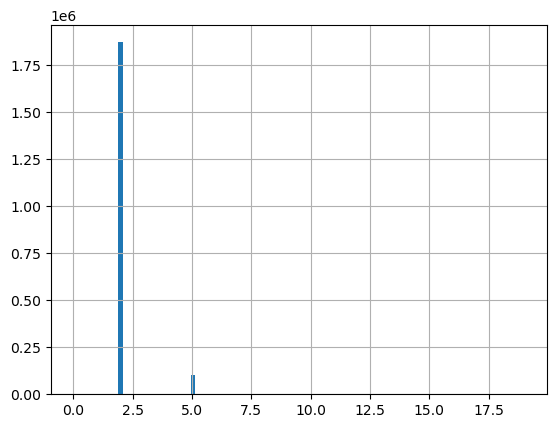

Histogram for pre_maxover2limit


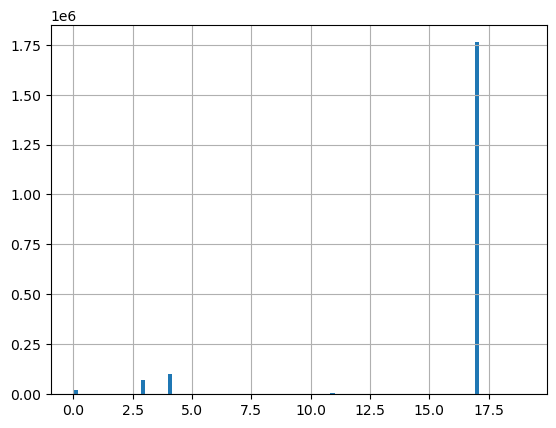

Histogram for is_zero_over2limit


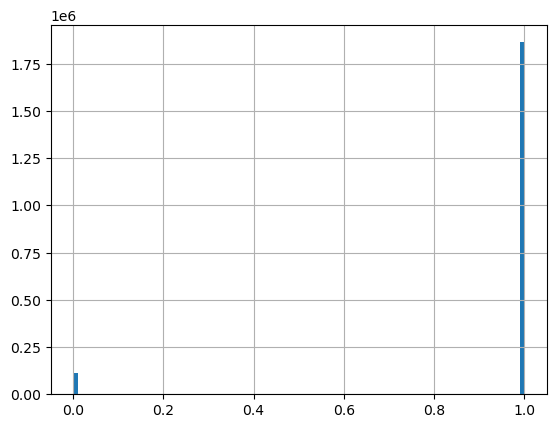

Histogram for is_zero_maxover2limit


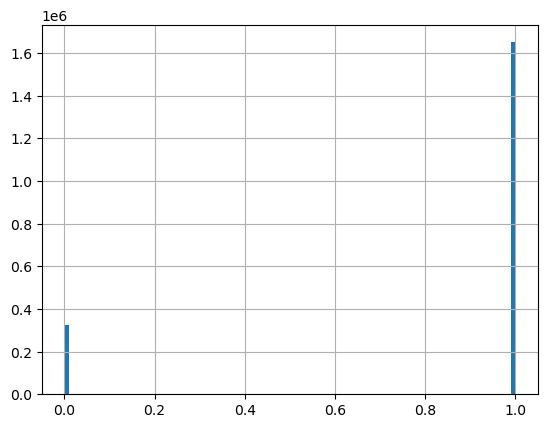

Histogram for enc_paym_0


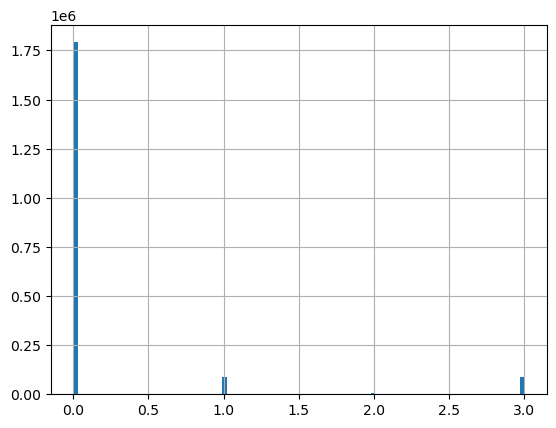

Histogram for enc_paym_1


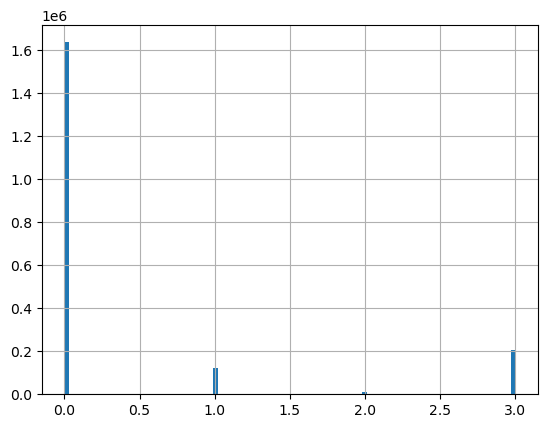

Histogram for enc_paym_2


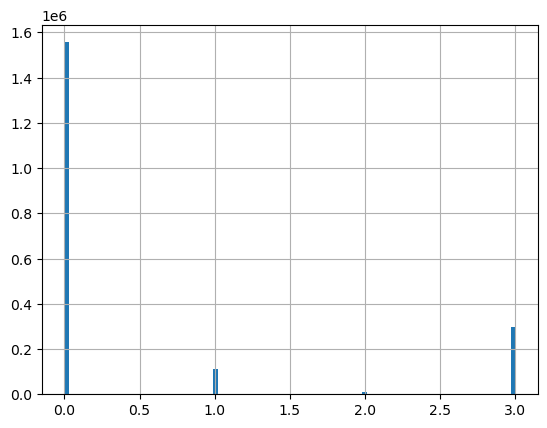

Histogram for enc_paym_3


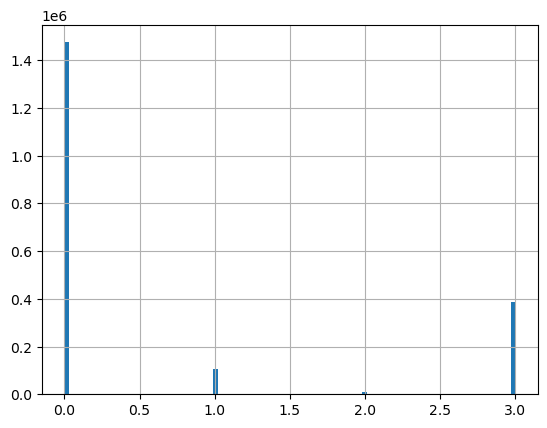

Histogram for enc_paym_4


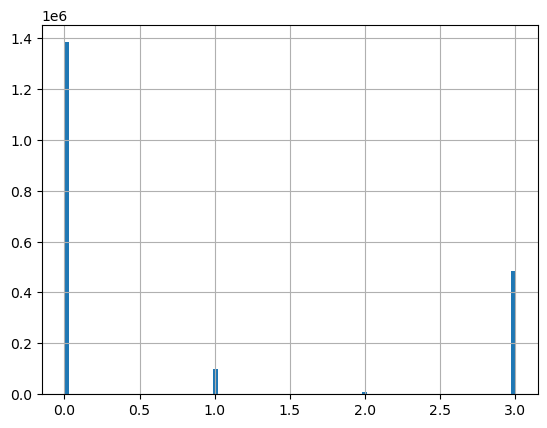

Histogram for enc_paym_20


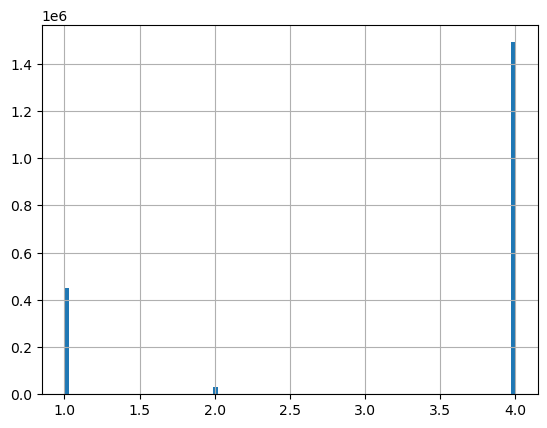

Histogram for enc_paym_21


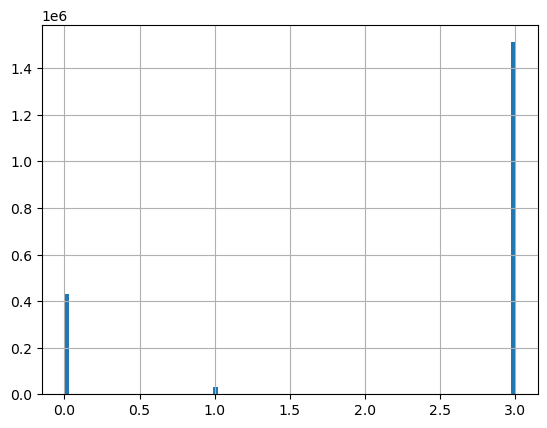

Histogram for enc_paym_22


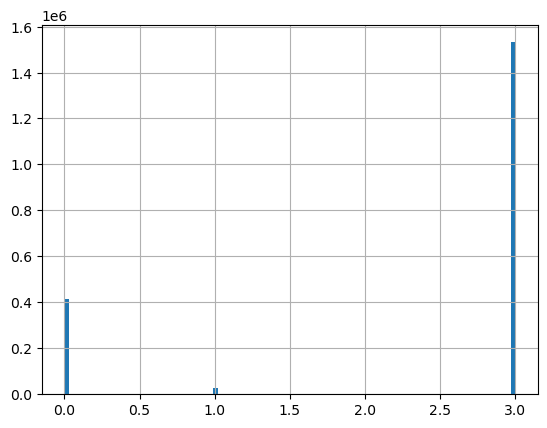

Histogram for enc_paym_23


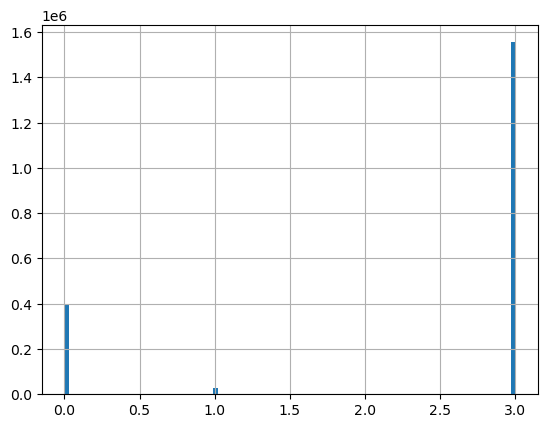

Histogram for enc_paym_24


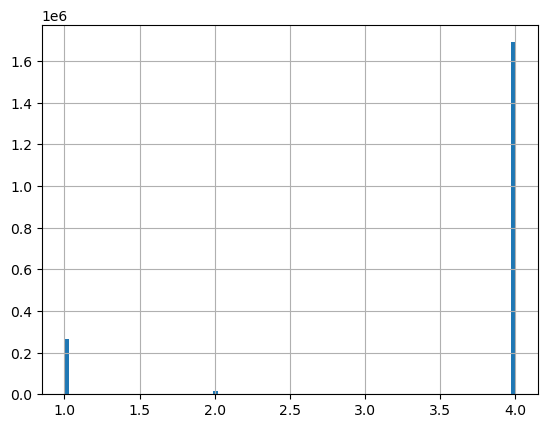

Histogram for enc_loans_account_holder_type


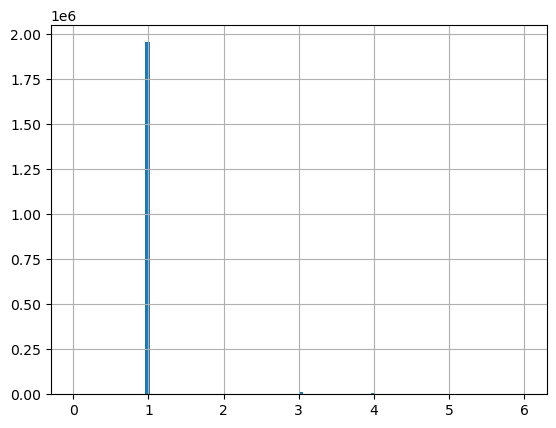

Histogram for enc_loans_credit_status


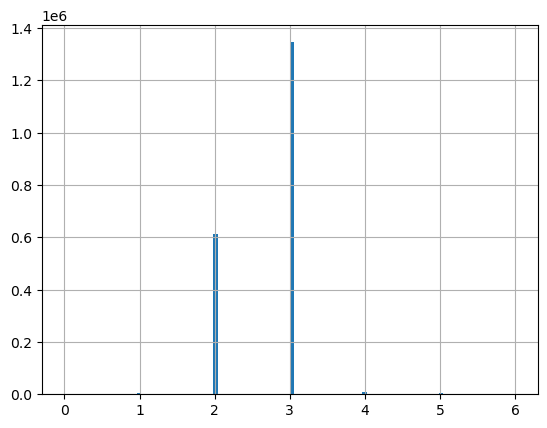

Histogram for enc_loans_credit_type


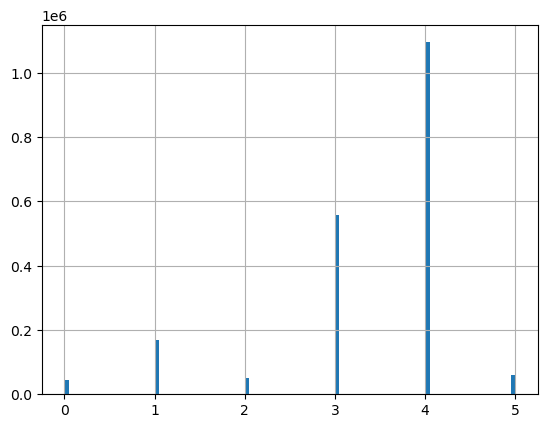

Histogram for enc_loans_account_cur


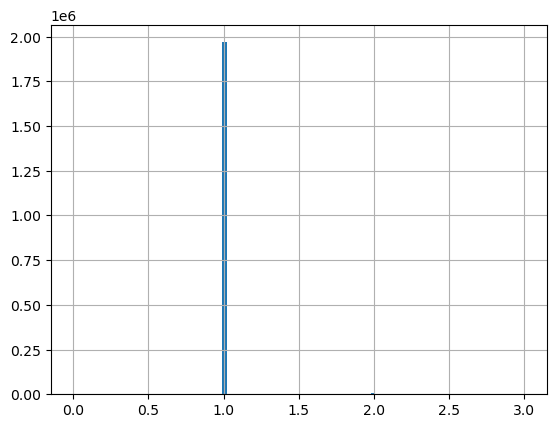

Histogram for pclose_flag


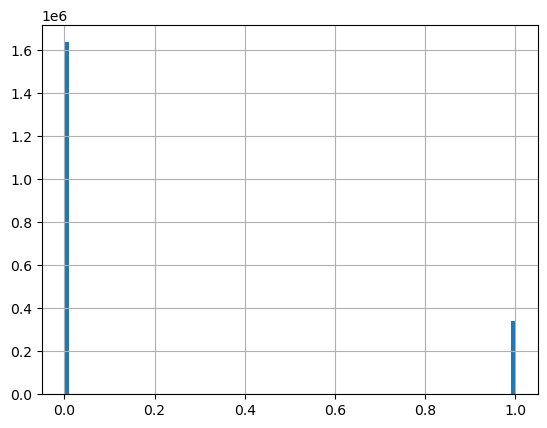

Histogram for fclose_flag


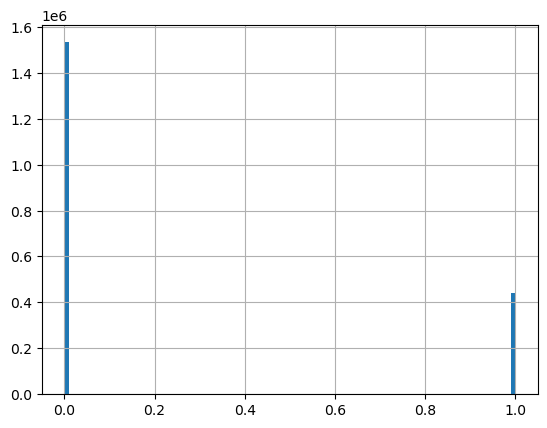

In [15]:
for col in columns_with_anomalies:
  print(f'Histogram for {col}')
  df[col].hist(bins=100)
  plt.show()


In [16]:
# Для начала определим, какие данные - это аномалия, а какие необходимость.

In [17]:
critical_columns = [
    'pre_since_opened',      # Дней с открытия - должно быть в разумных пределах
    'pre_since_confirmed',   # Дней с подтверждения - должно быть в разумных пределах
    'pre_pterm',             # Плановый срок - должен быть в разумных пределах
    'pre_fterm',             # Фактический срок - должен быть в разумных пределах
    'pre_till_pclose',       # Плановое время до закрытия
    'pre_till_fclose',       # Фактическое время до закрытия
    'pre_loans_credit_limit' # Кредитный лимит - должен быть в разумных пределах
]

Histogram for pre_since_opened


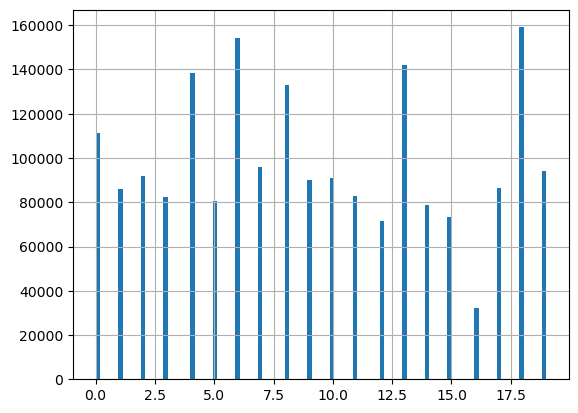

Histogram for pre_since_confirmed


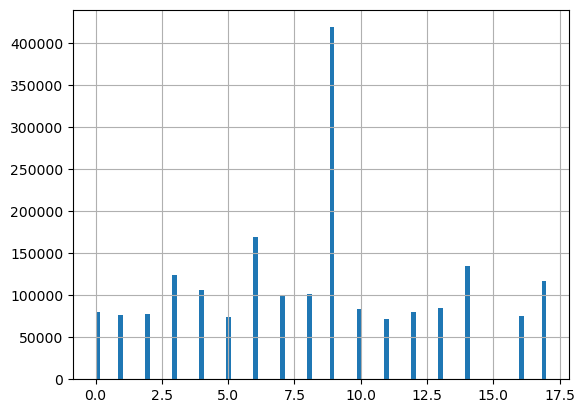

Histogram for pre_pterm


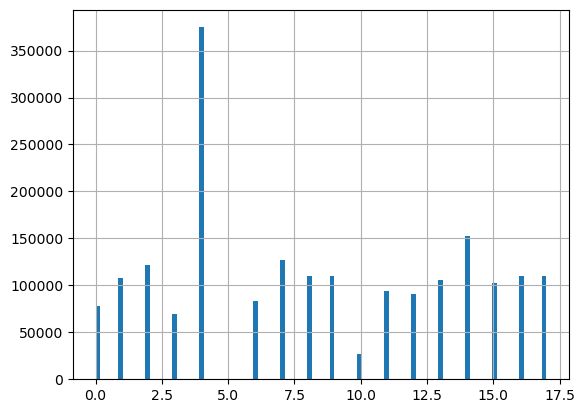

Histogram for pre_fterm


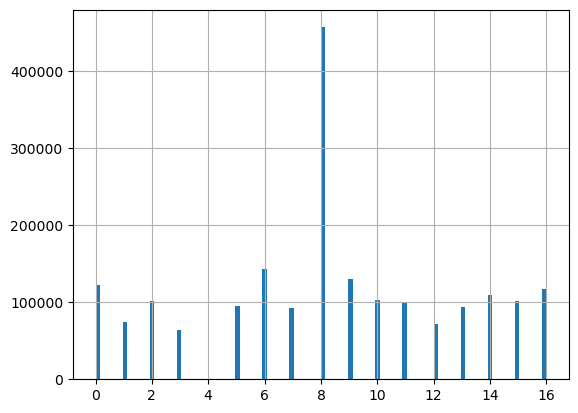

Histogram for pre_till_pclose


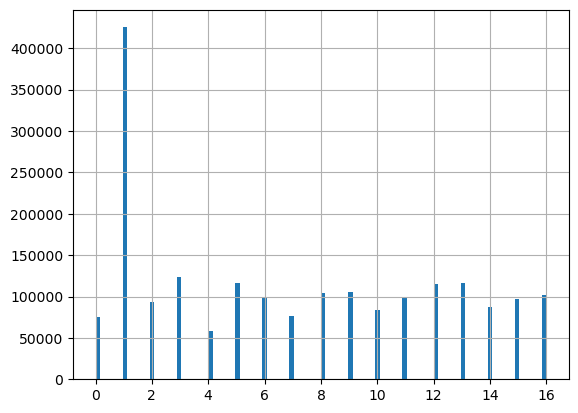

Histogram for pre_till_fclose


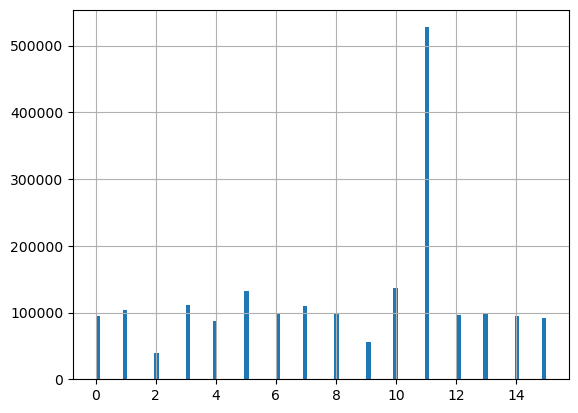

Histogram for pre_loans_credit_limit


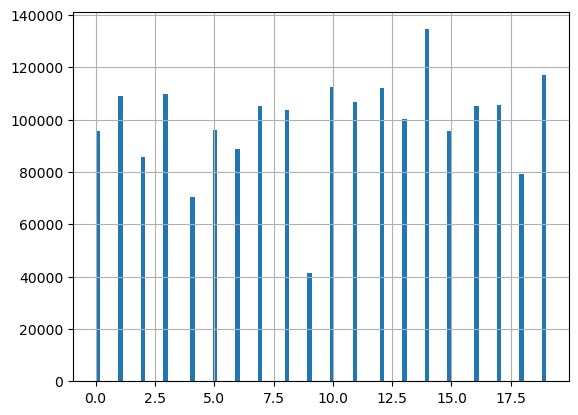

In [18]:
for col in critical_columns:
  print(f'Histogram for {col}')
  df[col].hist(bins=100)
  plt.show()


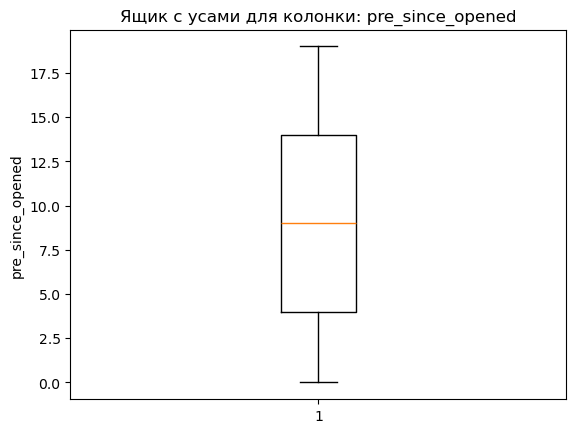

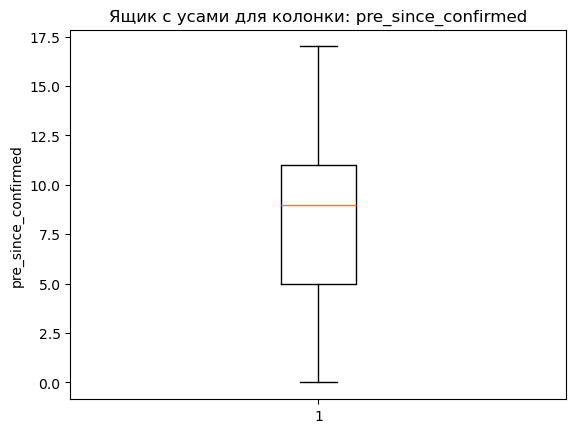

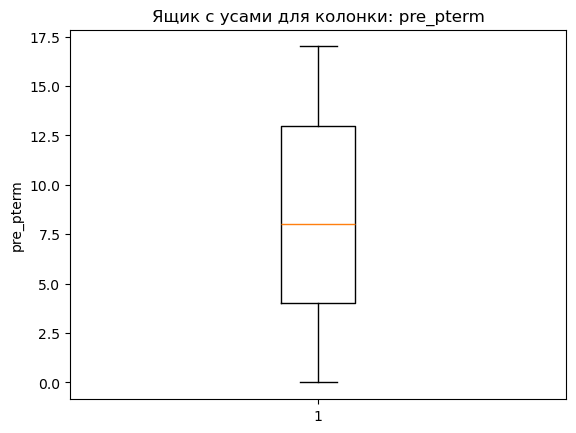

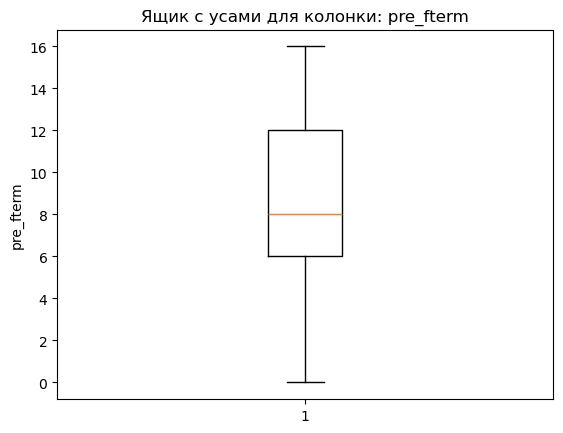

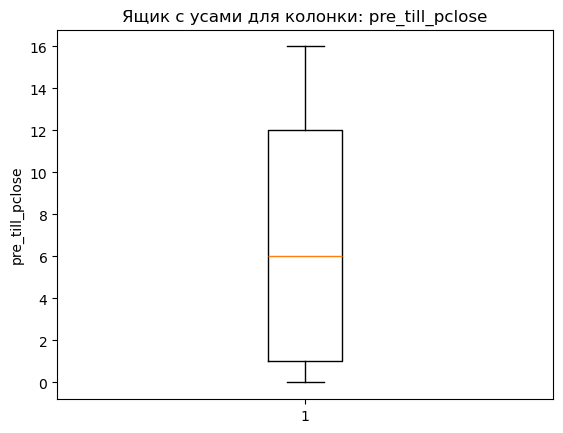

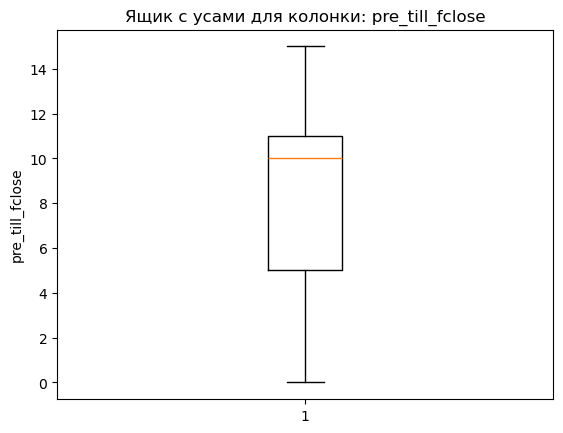

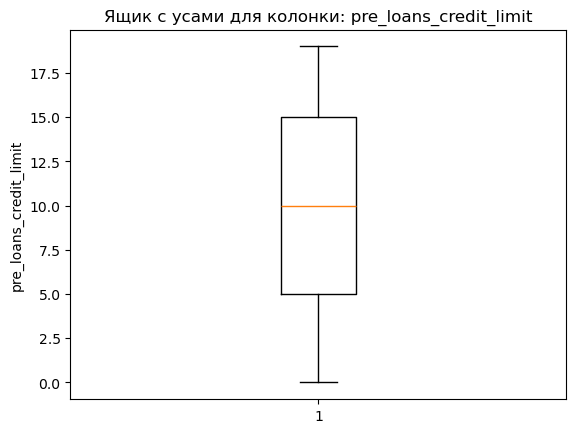

In [19]:
for col in critical_columns:
    plt.figure()  
    plt.boxplot(df[col])  
    plt.title(f'Ящик с усами для колонки: {col}')  
    plt.ylabel(col)  
    plt.show() 

In [20]:
# все аномалии - особенность данных, в чистке не нуждаются

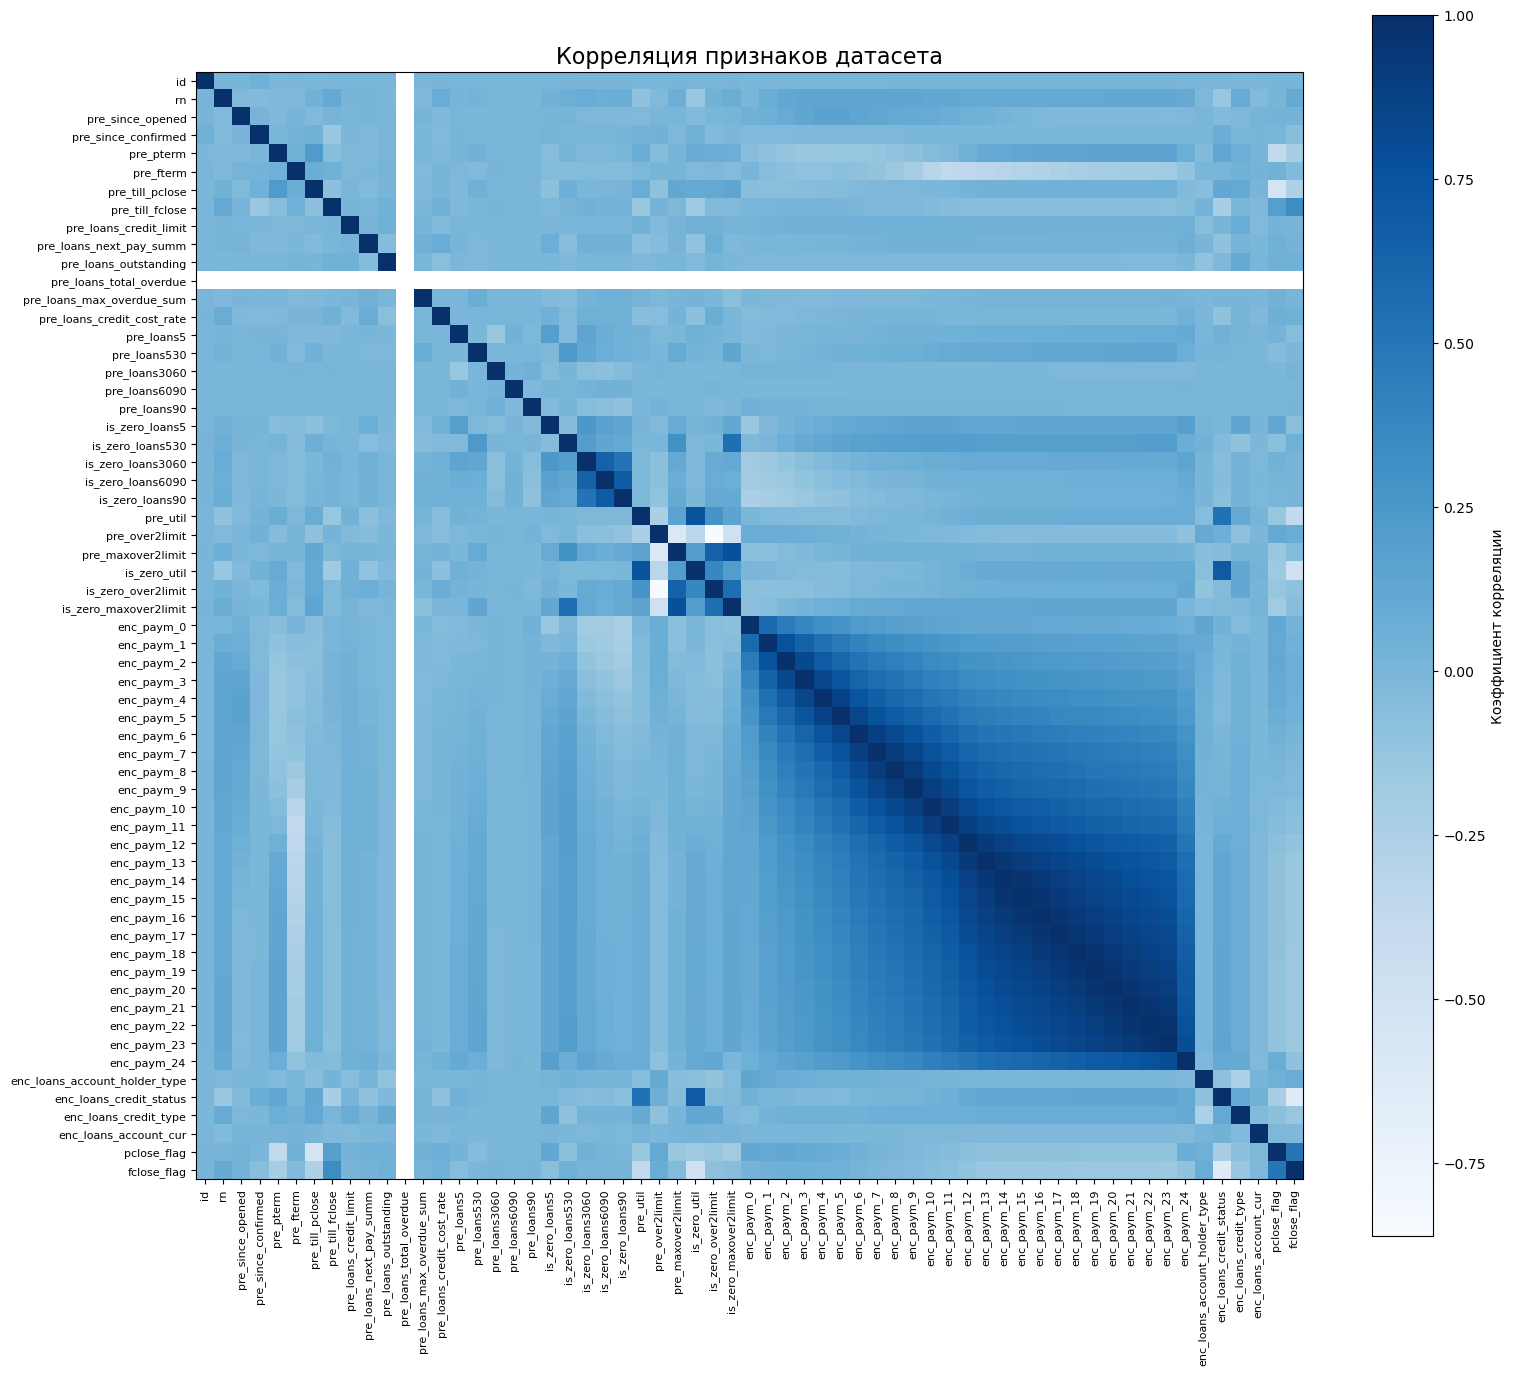

In [21]:
plt.figure(figsize=(16, 14))

# Получаем матрицу корреляции
corr_matrix = df.corr()
columns = corr_matrix.columns.tolist()

plt.imshow(corr_matrix, cmap='Blues', interpolation='nearest')

plt.title("Корреляция признаков датасета", fontsize=16)
plt.xticks(range(len(columns)), columns, rotation=90, fontsize=8)
plt.yticks(range(len(columns)), columns, fontsize=8)
plt.colorbar(label='Коэффициент корреляции')

plt.tight_layout()
plt.show()

In [9]:

def matrix_corr(df):
    corr_matrix = df.corr()
    # Находим пары признаков с корреляцией > 0.7 или < -0.7
    high_corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) > 0.7:
                high_corr_pairs.append((
                    corr_matrix.columns[i], 
                    corr_matrix.columns[j], 
                    corr_matrix.iloc[i, j]
                ))
    
    print("\n=== Пары признаков с высокой корреляцией (|r| > 0.7) ===\n")
    if high_corr_pairs:
        # Сортируем по абсолютному значению корреляции (по убыванию)
        high_corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)
        
        for pair in high_corr_pairs:
            print(f"  {pair[0]} и {pair[1]}: {pair[2]:.3f}")
        print(f"\nВсего найдено {len(high_corr_pairs)} сильно коррелирующих пар.")
    else:
        print("  Сильно коррелирующих пар признаков не найдено.")

In [10]:
matrix_corr(df)


=== Пары признаков с высокой корреляцией (|r| > 0.7) ===

  enc_paym_20 и enc_paym_21: 0.964
  enc_paym_21 и enc_paym_22: 0.963
  enc_paym_19 и enc_paym_20: 0.963
  enc_paym_18 и enc_paym_19: 0.961
  enc_paym_16 и enc_paym_17: 0.960
  enc_paym_15 и enc_paym_16: 0.959
  enc_paym_22 и enc_paym_23: 0.958
  enc_paym_14 и enc_paym_15: 0.956
  enc_paym_17 и enc_paym_18: 0.954
  enc_paym_13 и enc_paym_14: 0.948
  enc_paym_20 и enc_paym_22: 0.934
  enc_paym_19 и enc_paym_21: 0.934
  enc_paym_18 и enc_paym_20: 0.931
  enc_paym_21 и enc_paym_23: 0.928
  enc_paym_15 и enc_paym_17: 0.925
  enc_paym_14 и enc_paym_16: 0.922
  enc_paym_17 и enc_paym_19: 0.922
  enc_paym_12 и enc_paym_13: 0.922
  enc_paym_16 и enc_paym_18: 0.921
  enc_paym_8 и enc_paym_9: 0.914
  enc_paym_13 и enc_paym_15: 0.913
  enc_paym_10 и enc_paym_11: 0.911
  enc_paym_7 и enc_paym_8: 0.906
  enc_paym_19 и enc_paym_22: 0.905
  enc_paym_18 и enc_paym_21: 0.903
  enc_paym_20 и enc_paym_23: 0.901
  enc_paym_9 и enc_paym_10: 0.894
 

# Анализ targets

In [24]:
targets['flag'].value_counts()

flag
0    2893558
1     106442
Name: count, dtype: int64

In [25]:
targets['flag'].value_counts()/len(targets)

flag
0    0.964519
1    0.035481
Name: count, dtype: float64

# Фичи

In [41]:
# рассмотрим, что включают строки по 1 клиенту

In [40]:
df[df['id'] == 249998]

,id,rn,pre_since_opened,pre_since_confirmed,pre_pterm,pre_fterm,pre_till_pclose,pre_till_fclose,pre_loans_credit_limit,pre_loans_next_pay_summ,...,enc_loans_account_holder_type,enc_loans_credit_status,enc_loans_credit_type,enc_loans_account_cur,pclose_flag,fclose_flag,paym_mean,paym_std,paym_max,paym_min
1974716,249998,1,15,8,12,10,6,13,19,2,...,1,4,4,1,0,0,3.00,0.707107,4,0
1974717,249998,2,10,8,4,12,1,3,4,2,...,1,3,1,1,1,0,3.12,0.331662,4,3
1974718,249998,3,1,5,14,8,10,11,17,2,...,1,2,3,1,0,1,1.80,1.658312,4,0
1974719,249998,4,1,9,14,8,10,11,8,4,...,1,2,3,1,0,1,1.56,1.609348,4,0
1974720,249998,5,7,9,4,8,1,11,19,1,...,1,2,4,1,1,1,2.52,1.326650,4,0


In [79]:
# для начала не обходимо сгруппировать все признаки в 1 строку по клиентам, затем выявить новые фичи и провести чистку сильно коррелирующих признаков

In [14]:
# Бинарные (порядковые) признаки для One-Hot кодирования
binary_cols = [
    'pre_since_opened', 'pre_since_confirmed', 'pre_pterm', 'pre_fterm',
    'pre_till_pclose', 'pre_till_fclose', 'pre_loans_credit_limit',
    'pre_loans_next_pay_summ', 'pre_loans_outstanding', 'pre_loans_total_overdue',
    'pre_loans_max_overdue_sum', 'pre_loans_credit_cost_rate', 'pre_loans5',
    'pre_loans530', 'pre_loans3060', 'pre_loans6090', 'pre_loans90',
    'pre_util', 'pre_over2limit', 'pre_maxover2limit'
]

# Кодированные признаки (уже закодированные числами)
coded_cols = [
    'enc_paym_0', 'enc_paym_1', 'enc_paym_2', 'enc_paym_3', 'enc_paym_4',
    'enc_paym_5', 'enc_paym_6', 'enc_paym_7', 'enc_paym_8', 'enc_paym_9',
    'enc_paym_10', 'enc_paym_11', 'enc_paym_12', 'enc_paym_13', 'enc_paym_14',
    'enc_paym_15', 'enc_paym_16', 'enc_paym_17', 'enc_paym_18', 'enc_paym_19',
    'enc_paym_20', 'enc_paym_21', 'enc_paym_22', 'enc_paym_23', 'enc_paym_24',
    'enc_loans_account_holder_type', 'enc_loans_credit_status',
    'enc_loans_credit_type', 'enc_loans_account_cur'
]

# Флаговые признаки (0/1)
flag_cols = [
    'is_zero_loans5', 'is_zero_loans530', 'is_zero_loans3060',
    'is_zero_loans6090', 'is_zero_loans90', 'is_zero_util',
    'is_zero_over2limit', 'is_zero_maxover2limit', 'pclose_flag', 'fclose_flag'
]

In [15]:
# Объединяем для One-Hot кодирования
ohe_cols = binary_cols + coded_cols

In [16]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(min_frequency=250, sparse_output=False, dtype='int8')
ohe_data = pd.DataFrame(
    ohe.fit_transform(df[ohe_cols]),
    columns=ohe.get_feature_names_out()
)
df = df.join(ohe_data).drop(columns=ohe_cols)   # заменяем исходные на OHE-столбцы

In [17]:
# Количество кредитных продуктов на клиента
rn_df = df.groupby(['id'], as_index=False)[['rn']].count()

In [18]:
# Доли флагов (mean) – процент кредитов с признаком = 1
flag_df = df.groupby(['id'], as_index=False)[flag_cols].mean()

In [19]:
# Суммы OHE-признаков – сколько раз встречалась каждая категория
category_df = df.groupby(['id'], as_index=False)[ohe.get_feature_names_out()].sum()

In [20]:
#Объединение всех агрегированных таблиц в одну
df_agg = pd.merge(left=rn_df, right=flag_df, on='id')
df_agg = pd.merge(left=df_agg, right=category_df, on='id')

In [21]:
df_agg.shape

(250000, 355)

In [88]:
df_agg.head()

,id,rn,is_zero_loans5,is_zero_loans530,is_zero_loans3060,is_zero_loans6090,is_zero_loans90,is_zero_util,is_zero_over2limit,is_zero_maxover2limit,...,enc_loans_credit_type_0,enc_loans_credit_type_1,enc_loans_credit_type_2,enc_loans_credit_type_3,enc_loans_credit_type_4,enc_loans_credit_type_5,enc_loans_account_cur_0,enc_loans_account_cur_1,enc_loans_account_cur_2,enc_loans_account_cur_infrequent_sklearn
0,0,10,0.900000,1.000000,1.000000,1.000000,1.000000,0.600000,0.900000,0.900000,...,0,1,0,2,7,0,0,10,0,0
1,1,14,0.857143,0.714286,0.857143,0.857143,0.785714,0.714286,0.857143,0.785714,...,0,3,0,3,8,0,0,14,0,0
2,2,3,1.000000,0.666667,0.666667,0.666667,1.000000,0.333333,1.000000,0.666667,...,0,0,0,2,1,0,0,3,0,0
3,3,15,1.000000,1.000000,1.000000,1.000000,1.000000,0.533333,0.933333,0.933333,...,0,1,0,4,9,1,0,15,0,0
4,4,1,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0,0,0,1,0,0,0,1,0,0


In [89]:
matrix_corr(df_agg)


=== Пары признаков с высокой корреляцией (|r| > 0.7) ===

  rn и pre_loans_total_overdue_0: 1.000
  rn и pre_loans6090_4: 1.000
  pre_loans_total_overdue_0 и pre_loans6090_4: 1.000
  rn и pre_loans90_8: 1.000
  pre_loans_total_overdue_0 и pre_loans90_8: 1.000
  pre_loans6090_4 и pre_loans90_8: 1.000
  pre_loans3060_5 и pre_loans6090_4: 1.000
  rn и pre_loans3060_5: 1.000
  pre_loans_total_overdue_0 и pre_loans3060_5: 1.000
  pre_loans3060_5 и pre_loans90_8: 1.000
  pre_loans5_6 и pre_loans3060_5: 0.999
  pre_loans5_6 и pre_loans6090_4: 0.999
  rn и pre_loans5_6: 0.999
  pre_loans_total_overdue_0 и pre_loans5_6: 0.999
  pre_loans5_6 и pre_loans90_8: 0.999
  rn и enc_loans_account_cur_1: 0.999
  pre_loans_total_overdue_0 и enc_loans_account_cur_1: 0.999
  pre_loans6090_4 и enc_loans_account_cur_1: 0.999
  pre_loans90_8 и enc_loans_account_cur_1: 0.999
  pre_loans3060_5 и enc_loans_account_cur_1: 0.999
  pre_loans5_6 и enc_loans_account_cur_1: 0.999
  enc_paym_21_3 и enc_paym_22_3: 0.998

In [25]:
# Удаляем все столбцы, название которых начинается с 'is_zero_'
# Они дублируют информацию о нулевых значениях соответствующих сумм
cols_to_drop = [col for col in df_agg.columns if col.startswith('is_zero_')]
df_agg.drop(columns=cols_to_drop, inplace=True)

In [26]:
df_agg = df_agg.merge(targets, on='id', how='left')

In [27]:
# удалим все столбцы с корр больше 0,95

In [28]:
def get_columns_to_drop(df, target_col='flag', threshold=0.95, exclude_cols=None):
    
    if exclude_cols is None:
        exclude_cols = []
    
    # Столбцы-признаки (все, кроме целевой и исключаемых)
    feature_cols = [col for col in df.columns if col not in exclude_cols + [target_col]]
    
    if len(feature_cols) < 2:
        return []  # Недостаточно признаков для анализа
    
    # Матрица абсолютных корреляций
    corr_matrix = df[feature_cols].corr().abs()
    
    # Поиск пар выше порога
    high_corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i + 1, len(corr_matrix.columns)):
            r = corr_matrix.iloc[i, j]
            if r > threshold:
                high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], r))
    
    # Определяем, какие столбцы удалить
    to_drop = set()
    for col_i, col_j, _ in high_corr_pairs:
        if col_i in to_drop or col_j in to_drop:
            continue  
        
        # Корреляции с целевой переменной (по модулю)
        corr_i = abs(df[col_i].corr(df[target_col]))
        corr_j = abs(df[col_j].corr(df[target_col]))
        
        # Удаляем тот, у которого корреляция с целью меньше (или второй при равенстве)
        if corr_i >= corr_j:
            to_drop.add(col_j)
        else:
            to_drop.add(col_i)
    
    return list(to_drop)

In [29]:
to_drop_list = get_columns_to_drop(df_agg, target_col='flag', threshold=0.95, exclude_cols=['id'])
print("Столбцы для удаления:", to_drop_list)

Столбцы для удаления: ['pre_over2limit_2', 'enc_paym_18_3', 'enc_paym_13_3', 'enc_paym_14_3', 'pre_loans_total_overdue_0', 'pre_loans_outstanding_3', 'enc_paym_23_3', 'rn', 'enc_paym_11_1', 'enc_paym_17_0', 'enc_paym_20_4', 'enc_paym_12_0', 'enc_paym_14_0', 'enc_paym_18_0', 'enc_paym_6_0', 'enc_paym_9_0', 'enc_paym_4_3', 'enc_paym_3_0', 'pre_util_9', 'pre_loans3060_5', 'pre_loans5_6', 'enc_paym_15_3', 'enc_paym_12_3', 'enc_paym_6_3', 'enc_paym_10_0', 'enc_paym_4_0', 'pre_loans90_8', 'enc_paym_0_0', 'enc_paym_23_0', 'enc_loans_credit_status_3', 'enc_paym_8_3', 'pre_loans530_16', 'enc_loans_account_holder_type_1', 'pre_loans6090_4', 'enc_loans_account_cur_1', 'enc_paym_9_3', 'pre_loans_max_overdue_sum_2', 'enc_paym_13_0', 'enc_paym_16_0', 'enc_paym_22_3', 'enc_paym_8_0', 'enc_paym_19_3', 'pre_maxover2limit_4', 'enc_paym_16_3', 'enc_paym_2_0', 'enc_paym_21_0', 'enc_paym_21_3', 'enc_paym_20_1', 'enc_paym_11_4', 'enc_paym_1_0', 'pre_maxover2limit_17', 'enc_paym_17_3']


In [30]:
df_agg_clean = df_agg.drop(columns=to_drop_list)

In [96]:
matrix_corr(df_agg_clean)


=== Пары признаков с высокой корреляцией (|r| > 0.7) ===

  enc_paym_2_3 и enc_paym_3_3: 0.949
  enc_paym_5_0 и enc_paym_7_0: 0.949
  enc_paym_7_3 и enc_paym_10_3: 0.946
  pre_util_16 и enc_paym_24_4: 0.942
  enc_paym_19_0 и enc_paym_22_0: 0.939
  enc_paym_5_3 и enc_paym_7_3: 0.930
  enc_paym_15_0 и enc_paym_19_0: 0.926
  pre_till_pclose_4 и pre_till_fclose_9: 0.918
  pre_pterm_6 и pre_till_pclose_0: 0.914
  enc_paym_3_3 и enc_paym_5_3: 0.914
  enc_paym_1_3 и enc_paym_2_3: 0.911
  enc_paym_10_3 и enc_paym_24_4: 0.905
  pre_loans_next_pay_summ_2 и pre_util_16: 0.904
  pre_fterm_8 и pre_till_fclose_11: 0.899
  enc_paym_15_0 и enc_paym_22_0: 0.887
  pre_till_pclose_9 и pre_till_fclose_1: 0.887
  pre_util_16 и enc_loans_credit_type_4: 0.880
  pre_loans_next_pay_summ_2 и enc_paym_24_4: 0.873
  enc_paym_24_4 и enc_loans_credit_type_4: 0.873
  enc_paym_5_3 и enc_paym_10_3: 0.864
  enc_paym_1_3 и enc_paym_3_3: 0.856
  enc_paym_2_3 и enc_paym_5_3: 0.853
  enc_paym_22_0 и enc_paym_24_1: 0.851
 

In [98]:
# Удаляем все столбцы, начинающиеся с 'pre_till_pclose' – оставляем только pre_till_fclose
cols_till_pclose = [col for col in df_agg_clean.columns if col.startswith('pre_till_pclose')]
df_agg_clean.drop(columns=cols_till_pclose, inplace=True)
print(f"Удалено {len(cols_till_pclose)} столбцов pre_till_pclose*")

# Удаляем все столбцы, начинающиеся с 'pre_pterm' – оставляем pre_fterm
cols_pterm = [col for col in df_agg_clean.columns if col.startswith('pre_pterm')]
df_agg_clean.drop(columns=cols_pterm, inplace=True)
print(f"Удалено {len(cols_pterm)} столбцов pre_pterm*")

Удалено 17 столбцов pre_till_pclose*
Удалено 18 столбцов pre_pterm*


In [99]:
matrix_corr(df_agg_clean)


=== Пары признаков с высокой корреляцией (|r| > 0.7) ===

  enc_paym_2_3 и enc_paym_3_3: 0.949
  enc_paym_5_0 и enc_paym_7_0: 0.949
  enc_paym_7_3 и enc_paym_10_3: 0.946
  pre_util_16 и enc_paym_24_4: 0.942
  enc_paym_19_0 и enc_paym_22_0: 0.939
  enc_paym_5_3 и enc_paym_7_3: 0.930
  enc_paym_15_0 и enc_paym_19_0: 0.926
  enc_paym_3_3 и enc_paym_5_3: 0.914
  enc_paym_1_3 и enc_paym_2_3: 0.911
  enc_paym_10_3 и enc_paym_24_4: 0.905
  pre_loans_next_pay_summ_2 и pre_util_16: 0.904
  pre_fterm_8 и pre_till_fclose_11: 0.899
  enc_paym_15_0 и enc_paym_22_0: 0.887
  pre_util_16 и enc_loans_credit_type_4: 0.880
  pre_loans_next_pay_summ_2 и enc_paym_24_4: 0.873
  enc_paym_24_4 и enc_loans_credit_type_4: 0.873
  enc_paym_5_3 и enc_paym_10_3: 0.864
  enc_paym_1_3 и enc_paym_3_3: 0.856
  enc_paym_2_3 и enc_paym_5_3: 0.853
  enc_paym_22_0 и enc_paym_24_1: 0.851
  pre_util_16 и enc_paym_5_0: 0.848
  pre_util_16 и enc_paym_10_3: 0.843
  enc_paym_7_3 и enc_paym_24_4: 0.835
  enc_paym_5_0 и enc_loan

In [100]:
# проведем агрегации ежемясных платежей, так как они сильно коррелируют между собой, что логично, так как клиент придерживается общей модели поведения

In [101]:
# Определим месяцы и коды для платежных признаков
months = list(range(25))
codes = [0, 1, 2, 3, 4]

# 1. Создаём для каждого месяца столбец с общим числом записей (сумма one-hot по всем кодам)
for month in months:
    cols_month = [f'enc_paym_{month}_{code}' for code in codes if f'enc_paym_{month}_{code}' in df_agg_clean.columns]
    if cols_month:
        df_agg_clean[f'paym_total_{month}'] = df_agg_clean[cols_month].sum(axis=1)

# 2. Средний код платежа для каждого месяца (взвешенное среднее)
for month in months:
    cols_month = [f'enc_paym_{month}_{code}' for code in codes if f'enc_paym_{month}_{code}' in df_agg_clean.columns]
    if cols_month:
        weighted_sum = sum(code * df_agg_clean[f'enc_paym_{month}_{code}'] for code in codes if f'enc_paym_{month}_{code}' in df_agg_clean.columns)
        df_agg_clean[f'paym_avg_{month}'] = weighted_sum / df_agg_clean[f'paym_total_{month}'].replace(0, np.nan)

# 3. Доля просроченных записей (код > 1) для каждого месяца
for month in months:
    cols_overdue = [f'enc_paym_{month}_{code}' for code in codes if code > 1 and f'enc_paym_{month}_{code}' in df_agg_clean.columns]
    if cols_overdue:
        df_agg_clean[f'paym_overdue_{month}'] = df_agg_clean[cols_overdue].sum(axis=1) / df_agg_clean[f'paym_total_{month}'].replace(0, np.nan)

# 4. Агрегированные признаки по всем месяцам

paym_avg_cols = [f'paym_avg_{m}' for m in months if f'paym_avg_{m}' in df_agg_clean.columns]
df_agg_clean['paym_avg_total'] = df_agg_clean[paym_avg_cols].mean(axis=1)

paym_overdue_cols = [f'paym_overdue_{m}' for m in months if f'paym_overdue_{m}' in df_agg_clean.columns]
df_agg_clean['paym_overdue_ratio'] = df_agg_clean[paym_overdue_cols].mean(axis=1)

last6 = [f'paym_avg_{m}' for m in range(19, 25) if f'paym_avg_{m}' in df_agg_clean.columns]
first6 = [f'paym_avg_{m}' for m in range(0, 6) if f'paym_avg_{m}' in df_agg_clean.columns]
if last6 and first6:
    df_agg_clean['paym_trend'] = df_agg_clean[last6].mean(axis=1) - df_agg_clean[first6].mean(axis=1)

if paym_avg_cols:
    df_agg_clean['paym_volatility'] = df_agg_clean[paym_avg_cols].std(axis=1)

# 5. Удаляем все исходные one-hot столбцы enc_paym_*, а также временные столбцы paym_total_*, paym_avg_*, paym_overdue_*
# (оставляем только созданные агрегаты)
cols_to_drop = [col for col in df_agg_clean.columns 
                if col.startswith('enc_paym_') 
                or col.startswith('paym_total_') 
                or (col.startswith('paym_avg_') and col not in ['paym_avg_total'])
                or (col.startswith('paym_overdue_') and col not in ['paym_overdue_ratio'])]

df_agg_clean.drop(columns=cols_to_drop, inplace=True)

print(f"Удалено {len(cols_to_drop)} столбцов платежных кодов.")
print(f"Добавлены новые признаки: paym_avg_total, paym_overdue_ratio, paym_trend, paym_volatility")
print(f"Итоговое число признаков: {df_agg_clean.shape[1]}")

Удалено 139 столбцов платежных кодов.
Добавлены новые признаки: paym_avg_total, paym_overdue_ratio, paym_trend, paym_volatility
Итоговое число признаков: 201


In [102]:
matrix_corr(df_agg_clean)


=== Пары признаков с высокой корреляцией (|r| > 0.7) ===

  paym_avg_total и paym_overdue_ratio: 0.974
  pre_loans_next_pay_summ_2 и pre_util_16: 0.904
  pre_fterm_8 и pre_till_fclose_11: 0.899
  pre_util_16 и enc_loans_credit_type_4: 0.880
  pre_loans_credit_cost_rate_6 и enc_loans_credit_type_5: 0.822
  pre_loans_next_pay_summ_2 и enc_loans_credit_type_4: 0.795
  pre_till_fclose_11 и enc_loans_credit_status_2: 0.776
  pre_fterm_3 и enc_loans_credit_type_5: 0.737
  pre_fterm_1 и pre_till_fclose_4: 0.713
  pre_fterm_3 и pre_loans_credit_cost_rate_6: 0.708

Всего найдено 10 сильно коррелирующих пар.


In [107]:
# Удаляем явно лишние признаки на основе анализа
cols_to_drop_manual = ['paym_overdue_ratio', 'pre_loans_next_pay_summ_2']
df_agg_clean.drop(columns=cols_to_drop_manual, inplace=True)
print(f"Удалены столбцы: {cols_to_drop_manual}")

Удалены столбцы: ['paym_overdue_ratio', 'pre_loans_next_pay_summ_2']


In [108]:
matrix_corr(df_agg_clean)


=== Пары признаков с высокой корреляцией (|r| > 0.7) ===

  pre_fterm_8 и pre_till_fclose_11: 0.899
  pre_util_16 и enc_loans_credit_type_4: 0.880
  pre_loans_credit_cost_rate_6 и enc_loans_credit_type_5: 0.822
  pre_till_fclose_11 и enc_loans_credit_status_2: 0.776
  pre_fterm_3 и enc_loans_credit_type_5: 0.737
  pre_fterm_1 и pre_till_fclose_4: 0.713
  pre_fterm_3 и pre_loans_credit_cost_rate_6: 0.708

Всего найдено 7 сильно коррелирующих пар.


In [109]:
cols_to_remove = [
    'pre_fterm_8',
    'enc_loans_credit_type_4',
    'enc_loans_credit_type_5',
    'enc_loans_credit_status_2',
    'pre_fterm_1',
    'pre_fterm_3'
]

df_agg_clean.drop(columns=cols_to_remove, inplace=True, errors='ignore')
print(f"Удалено {len(cols_to_remove)} признаков.")
print(f"Итоговое число признаков: {df_agg_clean.shape[1]}")

Удалено 6 признаков.
Итоговое число признаков: 193


In [110]:
df_agg_clean.head()

,id,pclose_flag,fclose_flag,pre_since_opened_0,pre_since_opened_1,pre_since_opened_2,pre_since_opened_3,pre_since_opened_4,pre_since_opened_5,pre_since_opened_6,...,enc_loans_credit_type_1,enc_loans_credit_type_2,enc_loans_credit_type_3,enc_loans_account_cur_0,enc_loans_account_cur_2,enc_loans_account_cur_infrequent_sklearn,flag,paym_avg_total,paym_trend,paym_volatility
0,0,0.100000,0.200000,0,1,1,1,1,2,0,...,1,0,2,0,0,0,0,1.580000,-0.566667,1.521549
1,1,0.071429,0.142857,0,0,1,0,0,0,0,...,3,0,3,0,0,0,0,1.736081,-0.966984,1.106962
2,2,0.666667,0.666667,1,0,0,0,0,0,0,...,0,0,2,0,0,0,0,1.850000,-0.933333,0.988087
3,3,0.333333,0.400000,0,3,1,0,2,1,3,...,1,0,4,0,0,0,0,1.560000,-1.300000,1.522571
4,4,1.000000,1.000000,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,3.125000,1.000000,0.353553


In [111]:
df_agg_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Columns: 193 entries, id to paym_volatility
dtypes: float64(5), int64(2), int8(186)
memory usage: 57.7 MB
